Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re

In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.model_selection import RandomizedSearchCV

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
from sklearn.utils.class_weight import compute_sample_weight

In [7]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import GridSearchCV

In [8]:
from sklearn.model_selection import StratifiedGroupKFold

In [9]:
from sklearn.metrics import classification_report, roc_auc_score

In [76]:
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection as skm
from sklearn.svm import SVC

In [10]:
np.random.seed(3)

## Data Preparation

#### Exploratory Data Analysis

In [11]:
holc = pd.read_csv('seattle_tracts_holc.csv')
holc.head(5)

,GEOID,pct_holc_A,pct_holc_B,pct_holc_C,pct_holc_D,pct_holc_graded,holc_dominant_grade,holc_grade_score
0,53033005304,0.00000,4.483842e-01,0.000000,0.000000,0.448384,B,2.000000
1,53033005901,0.00000,1.365832e-01,0.284780,0.000000,0.421364,C,2.675854
2,53033005401,0.00000,3.948537e-07,0.030135,0.131897,0.162032,D,3.814013
3,53033010102,0.03148,1.978415e-01,0.171302,0.000000,0.400623,B,2.349012
4,53033000602,0.00000,0.000000e+00,0.000000,0.000000,0.000000,ungraded,NaN


In [12]:
holc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GEOID                181 non-null    int64  
 1   pct_holc_A           181 non-null    float64
 2   pct_holc_B           181 non-null    float64
 3   pct_holc_C           181 non-null    float64
 4   pct_holc_D           181 non-null    float64
 5   pct_holc_graded      181 non-null    float64
 6   holc_dominant_grade  181 non-null    object 
 7   holc_grade_score     141 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 11.4+ KB


In [13]:
print("holc duplicates:", holc.duplicated().sum())

holc duplicates: 0


In [14]:
parcels = pd.read_csv('seattle_parcels_with_tract.csv', low_memory = False)
parcels.head(5)

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
0,982870,2753,LR3 (M1),500,1.0,98122,3.0,8.0,1080.0,0.0,2.0,2.0,2021.0,0.0,3.0,340000.0,280000.0,340000.0,280000.0,53033007700
1,57900,1110,NR3,6322,1.0,98117,1.0,8.0,2320.0,230.0,3.0,1.0,1954.0,0.0,3.0,615000.0,390000.0,615000.0,390000.0,53033001600
2,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,0.0,300.0,0.0,0.0,53033002900
3,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,1279000.0,700.0,376000.0,128900.0,53033002900
4,390410,230,NR3,6750,1.0,98118,1.0,6.0,660.0,0.0,2.0,1.0,1918.0,0.0,3.0,308000.0,150000.0,308000.0,150000.0,53033011101


In [15]:
print("parcels duplicates:", parcels.duplicated().sum())

parcels duplicates: 181


In [16]:
parcels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Major               193074 non-null  int64  
 1   Minor               193074 non-null  int64  
 2   CurrentZoning       193074 non-null  object 
 3   SqFtLot             193074 non-null  int64  
 4   NbrLivingUnits      163499 non-null  float64
 5   ZipCode             147720 non-null  object 
 6   Stories             163499 non-null  float64
 7   BldgGrade           163499 non-null  float64
 8   SqFtTotLiving       163499 non-null  float64
 9   SqFtGarageAttached  163499 non-null  float64
 10  Bedrooms            163499 non-null  float64
 11  BathFullCount       163499 non-null  float64
 12  YrBuilt             163499 non-null  float64
 13  YrRenovated         163499 non-null  float64
 14  Condition           163499 non-null  float64
 15  ApprLandVal         189567 non-nul

In [17]:
parcels[parcels.duplicated(keep=False)].head()

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
1752,322604,9177,NC3-95 (M),484328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,53033001201
1753,322604,9177,NC3-95 (M),484328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,53033001201
3430,927620,200,LR3 (M2),6225,1.0,NaN,3.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801
3432,927620,200,LR3 (M2),6225,1.0,NaN,3.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801
3434,927620,200,LR3 (M2),6225,1.0,NaN,2.0,9.0,1200.0,0.0,3.0,0.0,2025.0,0.0,3.0,897000.0,1325000.0,897000.0,1325000.0,53033009801


In [18]:
parcels.groupby(['Major', 'Minor'])['GEOID'].nunique().max()

1

In [19]:
parcels.duplicated(subset=['Major', 'Minor']).sum()

np.int64(4082)

In [20]:
parcels = parcels.drop_duplicates()
parcels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192893 entries, 0 to 193073
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Major               192893 non-null  int64  
 1   Minor               192893 non-null  int64  
 2   CurrentZoning       192893 non-null  object 
 3   SqFtLot             192893 non-null  int64  
 4   NbrLivingUnits      163335 non-null  float64
 5   ZipCode             147636 non-null  object 
 6   Stories             163335 non-null  float64
 7   BldgGrade           163335 non-null  float64
 8   SqFtTotLiving       163335 non-null  float64
 9   SqFtGarageAttached  163335 non-null  float64
 10  Bedrooms            163335 non-null  float64
 11  BathFullCount       163335 non-null  float64
 12  YrBuilt             163335 non-null  float64
 13  YrRenovated         163335 non-null  float64
 14  Condition           163335 non-null  float64
 15  ApprLandVal         189386 non-null  fl

In [21]:
print("parcels duplicates:", parcels.duplicated().sum())

parcels duplicates: 0


In [22]:
acs = pd.read_csv('acs_tract_clean.csv')
acs.head(5)

,tractID,Median household income in the past 12 months (in 2024 inflation-adjusted dollars),Total:_x,Owner occupied,Renter occupied,Total:_y,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,...,pct_black,pct_asian,pct_amer_indian,pct_pacific_isl,pct_other_race,pct_two_plus_race,pct_renter_cost_burdened,pct_renter_severely_burdened,TRACTCE,GEOID
0,1.01,69577.0,1746,141,1605,3417,1693,652,0,422,...,0.190811,0.123500,0.000000,0.000000,0.038338,0.151888,0.443614,0.183178,101,53033000101
1,1.02,89840.0,2358,840,1518,4321,3121,362,0,431,...,0.083777,0.099745,0.000000,0.000000,0.052303,0.041888,0.563900,0.210804,102,53033000102
2,2.01,88833.0,2486,1269,1217,4953,2594,356,41,980,...,0.071876,0.197860,0.008278,0.000000,0.123360,0.074904,0.589154,0.171734,201,53033000201
3,2.02,138472.0,1549,1131,418,4404,2165,374,6,708,...,0.084923,0.160763,0.001362,0.000000,0.077203,0.184151,0.456938,0.358852,202,53033000202
4,3.00,135536.0,1201,865,336,2926,1797,179,11,612,...,0.061176,0.209159,0.003759,0.000342,0.007861,0.103554,0.324405,0.122024,300,53033000300


In [23]:
print("acs duplicates:", acs.duplicated().sum())

acs duplicates: 0


In [24]:
df = pd.merge(parcels, acs, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192893 entries, 0 to 192892
Data columns (total 59 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               192893 non-null  int64  
 1   Minor                                                                               192893 non-null  int64  
 2   CurrentZoning                                                                       192893 non-null  object 
 3   SqFtLot                                                                             192893 non-null  int64  
 4   NbrLivingUnits                                                                      163335 non-null  float64
 5   ZipCode                                                                             14

In [25]:
print("df duplicates after first merge:", df.duplicated().sum())

df duplicates after first merge: 0


In [26]:
df = pd.merge(df, holc, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192893 entries, 0 to 192892
Data columns (total 66 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               192893 non-null  int64  
 1   Minor                                                                               192893 non-null  int64  
 2   CurrentZoning                                                                       192893 non-null  object 
 3   SqFtLot                                                                             192893 non-null  int64  
 4   NbrLivingUnits                                                                      163335 non-null  float64
 5   ZipCode                                                                             14

In [27]:
print("df duplicates after second merge:", df.duplicated().sum())

df duplicates after second merge: 0


In [28]:
# How many of each HOLC grade do we have?
df['holc_dominant_grade'].value_counts()

holc_dominant_grade
B           75008
C           45366
ungraded    34488
D           28101
A            9930
Name: count, dtype: int64

In [29]:
# Drop the ungraded rows since we're comparing current data to HOLC grades
df_grades = df[df['holc_dominant_grade'] != 'ungraded']
df_grades['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    75008
C    45366
D    28101
A     9930
Name: count, dtype: int64

In [30]:
print("df duplicates after drop ungraded:", df_grades.duplicated().sum())

df duplicates after drop ungraded: 0


In [31]:
# print("df duplicates after drop columns:", df_col.duplicated().sum())

All of the confusion matrices for random forest, boosting, and the decision tree were perfect. We think this was because there were duplicate rows after the identifying columns were dropped, and some duplicate rows were in train and some were in test. To fix this, we will split based on GEOID, so that all rows with the same GEOID are in either train or test but not both. After that we will drop the identifying rows.

In [32]:
df_grades['GEOID'].value_counts()

GEOID
53033005600    3020
53033003000    2758
53033003100    2621
53033009900    2493
53033009500    2445
               ... 
53033026500      45
53033005303      25
53033005304       7
53033990100       6
53033026300       4
Name: count, Length: 141, dtype: int64

In [33]:
# Drop all other HOLC columns because of multicollinearity
df_no_holc = df_grades.drop(columns = ['pct_holc_A', 'pct_holc_B', 'pct_holc_C', 'pct_holc_D', 'pct_holc_graded', 'holc_grade_score'])
df_no_holc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 60 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               158405 non-null  int64  
 1   Minor                                                                               158405 non-null  int64  
 2   CurrentZoning                                                                       158405 non-null  object 
 3   SqFtLot                                                                             158405 non-null  int64  
 4   NbrLivingUnits                                                                      134017 non-null  float64
 5   ZipCode                                                                             120620 

In [34]:
print("df duplicates after drop HOLC columns:", df_no_holc.duplicated().sum())

df duplicates after drop HOLC columns: 0


In [35]:
# How many zip codes do we have?
df_no_holc['ZipCode'].value_counts()

ZipCode
98115         11807
98118         11787
98103         10142
98117          9220
98144          7207
98116          6627
98105          6450
98199          6345
98106          6196
98122          5947
98126          5795
98112          5779
98107          5738
98108          5347
98136          5017
98119          3763
98178          2315
98109          2219
98102          1844
98146           935
98125            93
98134            12
98177             3
98114             2
98104             2
98121             2
90108             1
98136-1728        1
98118-6116        1
sq                1
98018             1
98301             1
3                 1
98015             1
# 2               1
988122            1
98115-7942        1
# 3               1
98000             1
98199-3014        1
91844             1
0                 1
98013             1
98132             1
98103-8173        1
98                1
98118-3167        1
D1 south          1
98107-5353        1
981182019   

In [36]:
# Will dropping ZipCode change the proportion of the HOLC grades?
df_no_holc['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

In [37]:
df_no_zip = df_no_holc.drop(columns = ['ZipCode'])
df_no_zip['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

In [38]:
print("df duplicates after drop zip code column:", df_no_zip.duplicated().sum())

df duplicates after drop zip code column: 0


Drop zip code because it has a lot of null values, cleaning would result in even more null values, 
it doesn't change the grade proportions, and geographic location may be too close to HOLC grades.

In [39]:
# Will dropping rows with null values change the proportion of HOLC grades?
df_dropNaN = df_no_zip.dropna()
df_dropNaN['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.512663
C    0.283482
D    0.164364
A    0.039491
Name: proportion, dtype: float64

In [40]:
# Compare actual numbers
df_dropNaN['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    66012
C    36502
D    21164
A     5085
Name: count, dtype: int64

Numbers from earlier:   
holc_dominant_grade  
B    75045  
C    45421  
D    28137  
A     9931

Dropping all the rows with null values would change the percentage of the HOLC grades in the data set. 
Instead, create indicator columns for columns with missing values to note whether the value was missing and fill in nulls with an impossible value (-1) as a placeholder.

In [41]:
# Copy dataframe
df_clean = df_no_zip.copy()

In [42]:
for col in df_clean.select_dtypes(include = ['float64']).columns:
    if df_clean[col].isnull().any():
        # Create indicator column (1 = missing, 0 = real value)
        df_clean[f'{col}_is_missing'] = df_clean[col].isnull().astype(int)

        # Fill empty spaces with -1 placeholder
        df_clean[col] = df_clean[col].fillna(-1)

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 86 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   Major                                                                                          158405 non-null  int64  
 1   Minor                                                                                          158405 non-null  int64  
 2   CurrentZoning                                                                                  158405 non-null  object 
 3   SqFtLot                                                                                        158405 non-null  int64  
 4   NbrLivingUnits                                                                                 158405 non-null  float64
 5   Stories       

In [44]:
# Double check for null values
null_counts = df_clean.isnull().sum()
null_counts[null_counts > 0]

Series([], dtype: int64)

In [45]:
print("df duplicates after handle null values:", df_clean.duplicated().sum())

df duplicates after handle null values: 0


In [46]:
# Check zoning before one hot encoding
#pd.set_option('display.max_rows', None)
df_clean['CurrentZoning'].value_counts()

CurrentZoning
NR3                   88754
NR2                   11019
LR2 (M)                9609
LR3 (M)                9350
LR1 (M)                8688
                      ...  
MIO-50-LR1 RC (M)         1
IG1 U/65                  1
SM-RB 125 (M2)            1
MIO-105-NC3-55 (M)        1
MIO-70-NC3-95 (M)         1
Name: count, Length: 243, dtype: int64

The CurrentZoning column needs more cleaning to encode well.  
Create a density column with neighborhood residential (mostly single family homes) = 1, low rise residential buildings = 2, midrise residential buildings = 3, highrise residential buildings = 4, other (mixed use, commercial, industrial) = -1.  
Create is_mixed_use, is_commercial, and is_industrial as one hot encoded columns.

In [47]:
def extract_base(zone):
    if pd.isna(zone):
        return "UNKNOWN"
    
    z = zone.upper()

    # Remove (M), (M1), etc.
    z = re.sub(r"\(.*?\)", "", z)

    # Remove leading/trailing spaces
    z = z.strip()

    # Handle MIO overlays
    if z.startswith("MIO-"):
        parts = z.split("-")
        if len(parts) >= 2:
            z = "-".join(parts[2:]) if parts[1].isdigit() else "-".join(parts[1:])

    # Take first token before space or dash
    z = re.split(r"[ -]", z)[0]

    return z


def map_features(zone):
    base = extract_base(zone)

    # Density
    if base.startswith("NR"):
        density = 1
    elif base.startswith("LR"):
        density = 2
    elif base.startswith("MR"):
        density = 3
    elif base.startswith("HR"):
        density = 4
    else:
        density = -1

    # Mixed-use
    is_mixed_use = int(base.startswith("NC"))

    # Commercial
    is_commercial = int(base.startswith("C") and not base.startswith("NC"))

    # Industrial
    is_industrial = int(base.startswith(("IG","IC","II","IB","UI")))

    return density, is_mixed_use, is_commercial, is_industrial

In [48]:
df_clean[["density", "is_mixed_use", "is_commercial", "is_industrial"]] = (
    df_clean["CurrentZoning"]
    .apply(map_features)
    .apply(pd.Series)
)

In [49]:
df_clean[["CurrentZoning", "density", "is_mixed_use", "is_commercial", "is_industrial"]].head(20)

,CurrentZoning,density,is_mixed_use,is_commercial,is_industrial
0,LR3 (M1),2,0,0,0
2,NC2-55 (M),-1,1,0,0
3,NC2-55 (M),-1,1,0,0
4,NR3,1,0,0,0
5,NR3,1,0,0,0
6,NR3,1,0,0,0
7,LR2 (M),2,0,0,0
8,NC3-75 (M),-1,1,0,0
9,NR3,1,0,0,0
12,LR3 (M),2,0,0,0


In [50]:
# For final dataframe to use for tree based models, drop CurrentZoning
df_clean = df_clean.drop(columns = ['CurrentZoning'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158405 entries, 0 to 192891
Data columns (total 89 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   Major                                                                                          158405 non-null  int64  
 1   Minor                                                                                          158405 non-null  int64  
 2   SqFtLot                                                                                        158405 non-null  int64  
 3   NbrLivingUnits                                                                                 158405 non-null  float64
 4   Stories                                                                                        158405 non-null  float64
 5   BldgGrade     

In [51]:
print("df duplicates after handle zoning:", df_clean.duplicated().sum())

df duplicates after handle zoning: 0


In [52]:
df_clean['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473520
C    0.286392
D    0.177400
A    0.062687
Name: proportion, dtype: float64

Export clean data set.

In [53]:
df_clean.to_csv("df_clean.csv", index = False)

Split data so that all rows with the same GEOID are in either train or test so that train and test don't have duplicate rows and it's approximately an 80/20 split.

In [55]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=3)

for train_idx, test_idx in sgkf.split(
    df_clean,
    df_clean['holc_dominant_grade'],
    groups=df_clean['GEOID']
):
    train = df_clean.iloc[train_idx]
    test = df_clean.iloc[test_idx]
    break  # take the first split (~80/20)

In [56]:
print(len(set(train['GEOID']).intersection(set(test['GEOID']))))

0


Split data and drop identifying columns.

In [57]:
X_train = train.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_train = train['holc_dominant_grade']

X_test = test.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_test = test['holc_dominant_grade']

In [58]:
y_train.value_counts(normalize = True)

holc_dominant_grade
B    0.488678
C    0.251310
D    0.185384
A    0.074629
Name: proportion, dtype: float64

In [59]:
y_test.value_counts(normalize = True)

holc_dominant_grade
C    0.470567
B    0.393948
D    0.135485
Name: proportion, dtype: float64

In [60]:
# Try a different split to try to get at least some A in test
for train1_idx, test1_idx in sgkf.split(
    df_clean,
    df_clean['holc_dominant_grade'],
    groups=df_clean['GEOID']
):
    train1 = df_clean.iloc[train1_idx]
    test1 = df_clean.iloc[test1_idx]
    
    if (test1['holc_dominant_grade'] == 'A').any():
        break

In [61]:
X_train = train1.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_train = train1['holc_dominant_grade']

X_test = test1.drop(columns=[
    'holc_dominant_grade',
    'Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'
])

y_test = test1['holc_dominant_grade']

In [62]:
print(y_test.value_counts(normalize=True))

holc_dominant_grade
B    0.478865
D    0.282380
C    0.186018
A    0.052737
Name: proportion, dtype: float64


In [63]:
print(y_train.value_counts(normalize=True))

holc_dominant_grade
B    0.472296
C    0.309386
D    0.153351
A    0.064967
Name: proportion, dtype: float64


In [64]:
print("Shared GEOIDs:", len(set(train1['GEOID']).intersection(set(test1['GEOID']))))

Shared GEOIDs: 0


## Modeling

#### Random Forest model

In [90]:
# Weight the classes since they're not balanced
# Max features cross validate p/3, sqrt(p), p/2
rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 3)

In [91]:
rf.fit(X_train,y_train)

# Predict values
y_pred_rf = rf.predict(X_test)

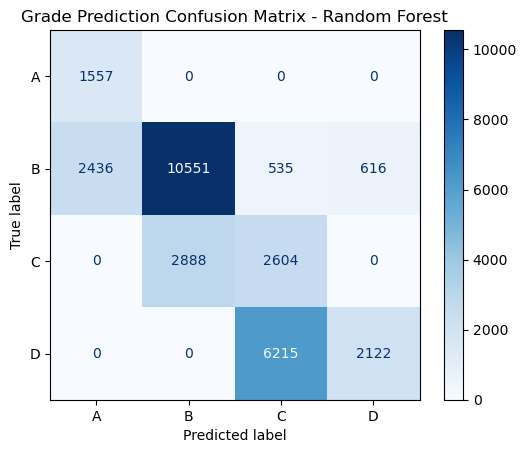

In [92]:
cm = confusion_matrix(y_test, y_pred_rf, labels = rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = rf.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Random Forest")
plt.show()

In [130]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           A       0.39      1.00      0.56      1557
           B       0.79      0.75      0.77     14138
           C       0.28      0.47      0.35      5492
           D       0.78      0.25      0.38      8337

    accuracy                           0.57     29524
   macro avg       0.56      0.62      0.52     29524
weighted avg       0.67      0.57      0.57     29524



In [131]:
y_probs_rf = rf.predict_proba(X_test)

roc_auc_rf = roc_auc_score(y_test, y_probs_rf, multi_class="ovr")

print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.7862615381158682


In [94]:
# create a dataframe of feature importances and their corresponding column names
importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
importances_rf = importances_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_rf)

                                              Feature    Importance
0                                           pct_white  9.071918e-02
1   Median household income in the past 12 months ...  6.238137e-02
2                                   pct_two_plus_race  5.563576e-02
3                                           pct_black  5.124245e-02
4                                  Two or More Races:  4.705465e-02
..                                                ...           ...
78                      SqFtGarageAttached_is_missing  2.932805e-16
79                             ApprLandVal_is_missing  2.922460e-16
80                                Bedrooms_is_missing  2.744784e-16
81                          NbrLivingUnits_is_missing  1.960860e-16
82                       pct_two_plus_race_is_missing  0.000000e+00

[83 rows x 2 columns]


Tune parameters using cross validation.

In [120]:
p = len(X_train.columns)
param_grid_rf = {"max_features": ["sqrt", "log2", p//2, p//3],
                 "n_estimators": [200, 500, 1000],  
                 "max_depth": [None, 10, 20, 30],
                 "min_samples_split": [2, 5, 10],
                 "min_samples_leaf": [1, 2, 5]}           

cv_rf = RandomizedSearchCV(estimator = rf,
                           param_distributions = param_grid_rf,
                           n_iter = 50,
                           cv = 5,
                           scoring = {"roc_auc": "roc_auc_ovr",
                                      "f1": "f1_weighted"},
                           refit = "roc_auc",
                           random_state = 3,
                           n_jobs = -1
                          )

cv_rf.fit(X_train, y_train)


print("Best Parameters Found:", cv_rf.best_params_)
print("Best Cross-Validation Score:", cv_rf.best_score_)

Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 41, 'max_depth': 30}
Best Cross-Validation Score: 1.0


In [121]:
y_pred_rf_best = cv_rf.best_estimator_.predict(X_test)

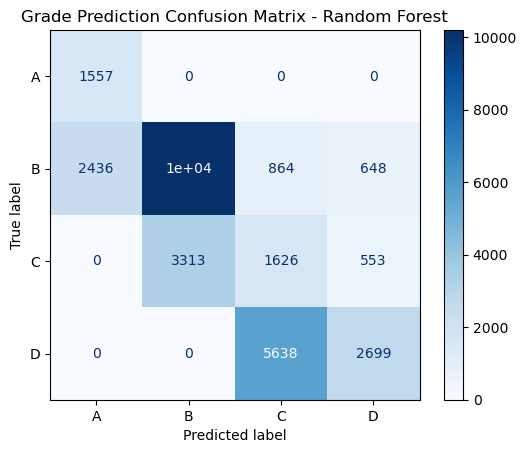

In [122]:
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best, labels = rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_rf_best, display_labels = rf.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Random Forest")
plt.show()

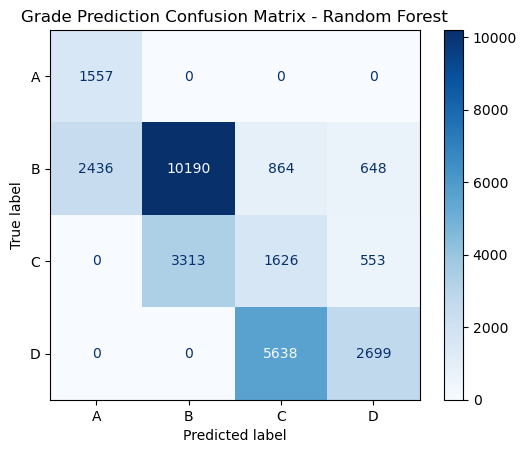

In [123]:
disp.plot(cmap = plt.cm.Blues, values_format = 'd')
plt.title("Grade Prediction Confusion Matrix - Random Forest")
plt.show()

In [125]:
print(classification_report(y_test, y_pred_rf_best))

              precision    recall  f1-score   support

           A       0.39      1.00      0.56      1557
           B       0.75      0.72      0.74     14138
           C       0.20      0.30      0.24      5492
           D       0.69      0.32      0.44      8337

    accuracy                           0.54     29524
   macro avg       0.51      0.59      0.49     29524
weighted avg       0.61      0.54      0.55     29524



In [129]:
y_probs_rf_best = cv_rf.best_estimator_.predict_proba(X_test)

roc_auc_rf_best = roc_auc_score(y_test, y_probs_rf_best, multi_class="ovr")

print("ROC-AUC:", roc_auc_rf_best)

ROC-AUC: 0.8230459697443719


In [132]:
# create a dataframe of feature importances and their corresponding column names for the best random forest model
importances_rf_best = pd.DataFrame({'Feature': X_train.columns, 'Importance': cv_rf.best_estimator_.feature_importances_})
importances_rf_best = importances_rf_best.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_rf_best)

                                              Feature    Importance
0                                           pct_white  1.590049e-01
1   Median household income in the past 12 months ...  1.447709e-01
2                                  Two or More Races:  8.397355e-02
3                                   pct_two_plus_race  6.027466e-02
4                                           pct_black  4.387483e-02
..                                                ...           ...
78                                Bedrooms_is_missing  3.829386e-16
79                                        YrRenovated  3.031674e-16
80                                       is_mixed_use  2.694496e-16
81                          pct_other_race_is_missing  0.000000e+00
82            pct_renter_severely_burdened_is_missing  0.000000e+00

[83 rows x 2 columns]


#### Boosting

In [95]:
# fit Gradient Boosting model
boost = GradientBoostingClassifier(random_state=3)
training_weights = compute_sample_weight(class_weight = 'balanced', y = y_train)
boost.fit(X_train, y_train, sample_weight = training_weights)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [96]:
# create a dataframe of feature importances and their corresponding column names
importances_boost = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost.feature_importances_})
importances_boost = importances_boost.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost)

                                              Feature  Importance
0   Median household income in the past 12 months ...    0.185342
1                                25.0 to 29.9 percent    0.145896
2                                  Two or More Races:    0.126586
3                                           pct_white    0.104376
4                                           pct_asian    0.058853
..                                                ...         ...
78                             ApprLandVal_is_missing    0.000000
79                               Condition_is_missing    0.000000
80                             YrRenovated_is_missing    0.000000
81                                 YrBuilt_is_missing    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


In [97]:
# Predict values
y_pred_boost = boost.predict(X_test)

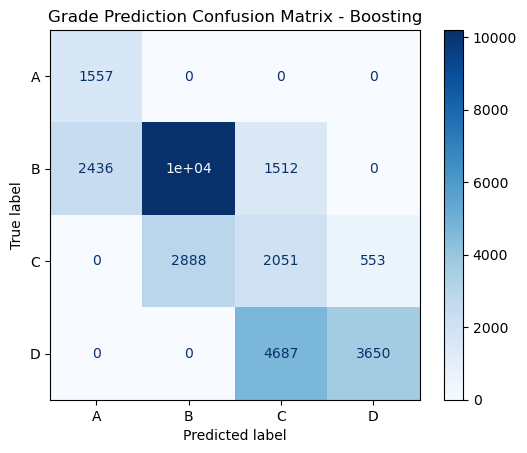

In [98]:
# Create a confusion matrix
cm_boost = confusion_matrix(y_test, y_pred_boost, labels = boost.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_boost, display_labels = boost.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Boosting")
plt.show()

In [133]:
print(classification_report(y_test, y_pred_boost))

              precision    recall  f1-score   support

           A       0.39      1.00      0.56      1557
           B       0.78      0.72      0.75     14138
           C       0.25      0.37      0.30      5492
           D       0.87      0.44      0.58      8337

    accuracy                           0.59     29524
   macro avg       0.57      0.63      0.55     29524
weighted avg       0.69      0.59      0.61     29524



In [134]:
y_probs_boost = boost.predict_proba(X_test)

roc_auc_boost = roc_auc_score(y_test, y_probs_boost, multi_class="ovr")

print("ROC-AUC:", roc_auc_boost)

ROC-AUC: 0.8113020627969633


Tune the parameters of the boosting model

In [65]:
boost = GradientBoostingClassifier(random_state=3)
param_grid_boost = {"learning_rate": [0.1, 0.01],
                    "n_estimators": [200, 500, 800],
                    "max_depth": [3, 4, 5]}
       

cv_boost = RandomizedSearchCV(estimator = boost,
                              param_distributions = param_grid_boost,
                              n_iter = 12,
                              cv = 5,
                              scoring = {"roc_auc": "roc_auc_ovr",
                                         "f1": "f1_weighted"},
                              refit = "roc_auc",
                              random_state = 3,
                              verbose = 2,
                              n_jobs = -1)

training_weights = compute_sample_weight(class_weight = 'balanced', y = y_train)

cv_boost.fit(X_train, y_train, sample_weight = training_weights)


print("Best Parameters Found:", cv_boost.best_params_)
print("Best Cross-Validation Score:", cv_boost.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters Found: {'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.01}
Best Cross-Validation Score: 1.0


In [66]:
best_boost_model = cv_boost.best_estimator_

In [67]:
# create a dataframe of feature importances and their corresponding column names
importances_best_boost = pd.DataFrame({'Feature': X_train.columns, 'Importance': best_boost_model.feature_importances_})
importances_best_boost = importances_best_boost.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_best_boost)

                                              Feature  Importance
0   Median household income in the past 12 months ...    0.186832
1                                25.0 to 29.9 percent    0.145886
2                                  Two or More Races:    0.127306
3                                           pct_white    0.106097
4                                20.0 to 24.9 percent    0.053178
..                                                ...         ...
78                          TaxableLandVal_is_missing    0.000000
79                                          Condition    0.000000
80                             ApprLandVal_is_missing    0.000000
81                          TaxableImpsVal_is_missing    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


In [68]:
y_pred_boost_best = best_boost_model.predict(X_test)

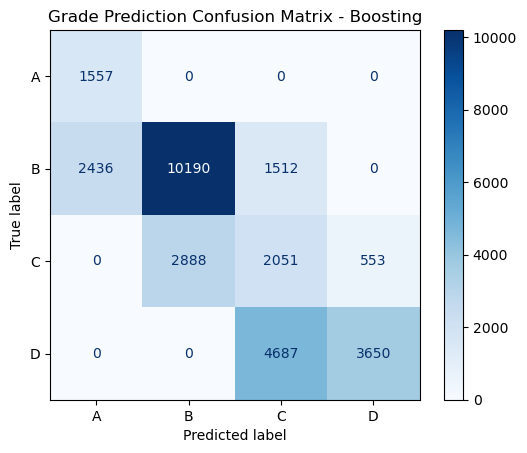

In [74]:
cm_boost_best = confusion_matrix(y_test, y_pred_boost_best, labels = cv_boost.classes_)
disp_bb = ConfusionMatrixDisplay(confusion_matrix = cm_boost_best, display_labels = cv_boost.classes_)

disp_bb.plot(cmap = plt.cm.Blues, values_format = 'd')
plt.title("Grade Prediction Confusion Matrix - Boosting")
plt.show()

In [72]:
print(classification_report(y_test, y_pred_boost_best))

              precision    recall  f1-score   support

           A       0.39      1.00      0.56      1557
           B       0.78      0.72      0.75     14138
           C       0.25      0.37      0.30      5492
           D       0.87      0.44      0.58      8337

    accuracy                           0.59     29524
   macro avg       0.57      0.63      0.55     29524
weighted avg       0.69      0.59      0.61     29524



In [73]:
y_probs_boost_best = best_boost_model.predict_proba(X_test)

roc_auc_boost_best = roc_auc_score(y_test, y_probs_boost_best, multi_class="ovr")

print("ROC-AUC:", roc_auc_boost_best)

ROC-AUC: 0.7934137697638224


#### Decision Tree

In [83]:
# fit decision tree model
tree = DecisionTreeClassifier(class_weight = 'balanced', random_state = 3)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [84]:
# create a dataframe of feature importances and their corresponding column names
importances_tree = pd.DataFrame({'Feature': X_train.columns, 'Importance': tree.feature_importances_})
importances_tree = importances_tree.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_tree)

                                              Feature  Importance
0   Median household income in the past 12 months ...    0.207024
1                                           pct_white    0.150333
2                                  Two or More Races:    0.137135
3                                25.0 to 29.9 percent    0.120565
4                                20.0 to 24.9 percent    0.077492
..                                                ...         ...
78                               50.0 percent or more    0.000000
79                                     NbrLivingUnits    0.000000
80                                          pct_black    0.000000
81                                    pct_pacific_isl    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


Print a text summary of the decision tree.

In [100]:
tree_summary = export_text(tree, feature_names=X_train.columns.tolist())
print(tree_summary)

|--- Median household income in the past 12 months (in 2024 inflation-adjusted dollars) <= 219004.00
|   |--- Two or More Races: <= 821.00
|   |   |--- 25.0 to 29.9 percent <= 2.50
|   |   |   |--- Less than 10.0 percent <= 0.50
|   |   |   |   |--- class: D
|   |   |   |--- Less than 10.0 percent >  0.50
|   |   |   |   |--- class: A
|   |   |--- 25.0 to 29.9 percent >  2.50
|   |   |   |--- pct_white <= 0.44
|   |   |   |   |--- Owner occupied <= 155.00
|   |   |   |   |   |--- 25.0 to 29.9 percent <= 201.50
|   |   |   |   |   |   |--- Not computed <= 160.00
|   |   |   |   |   |   |   |--- class: B
|   |   |   |   |   |   |--- Not computed >  160.00
|   |   |   |   |   |   |   |--- class: C
|   |   |   |   |   |--- 25.0 to 29.9 percent >  201.50
|   |   |   |   |   |   |--- class: D
|   |   |   |   |--- Owner occupied >  155.00
|   |   |   |   |   |--- Two races including Some Other Race <= 336.00
|   |   |   |   |   |   |--- class: C
|   |   |   |   |   |--- Two races including So

Find the importance of each feature.

In [101]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': tree.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                                         feature_name  importance
0   Median household income in the past 12 months ...    0.207024
1                                           pct_white    0.150333
2                                  Two or More Races:    0.137135
3                                25.0 to 29.9 percent    0.120565
4                                20.0 to 24.9 percent    0.077492
..                                                ...         ...
78                               50.0 percent or more    0.000000
79                                     NbrLivingUnits    0.000000
80                                          pct_black    0.000000
81                                    pct_pacific_isl    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


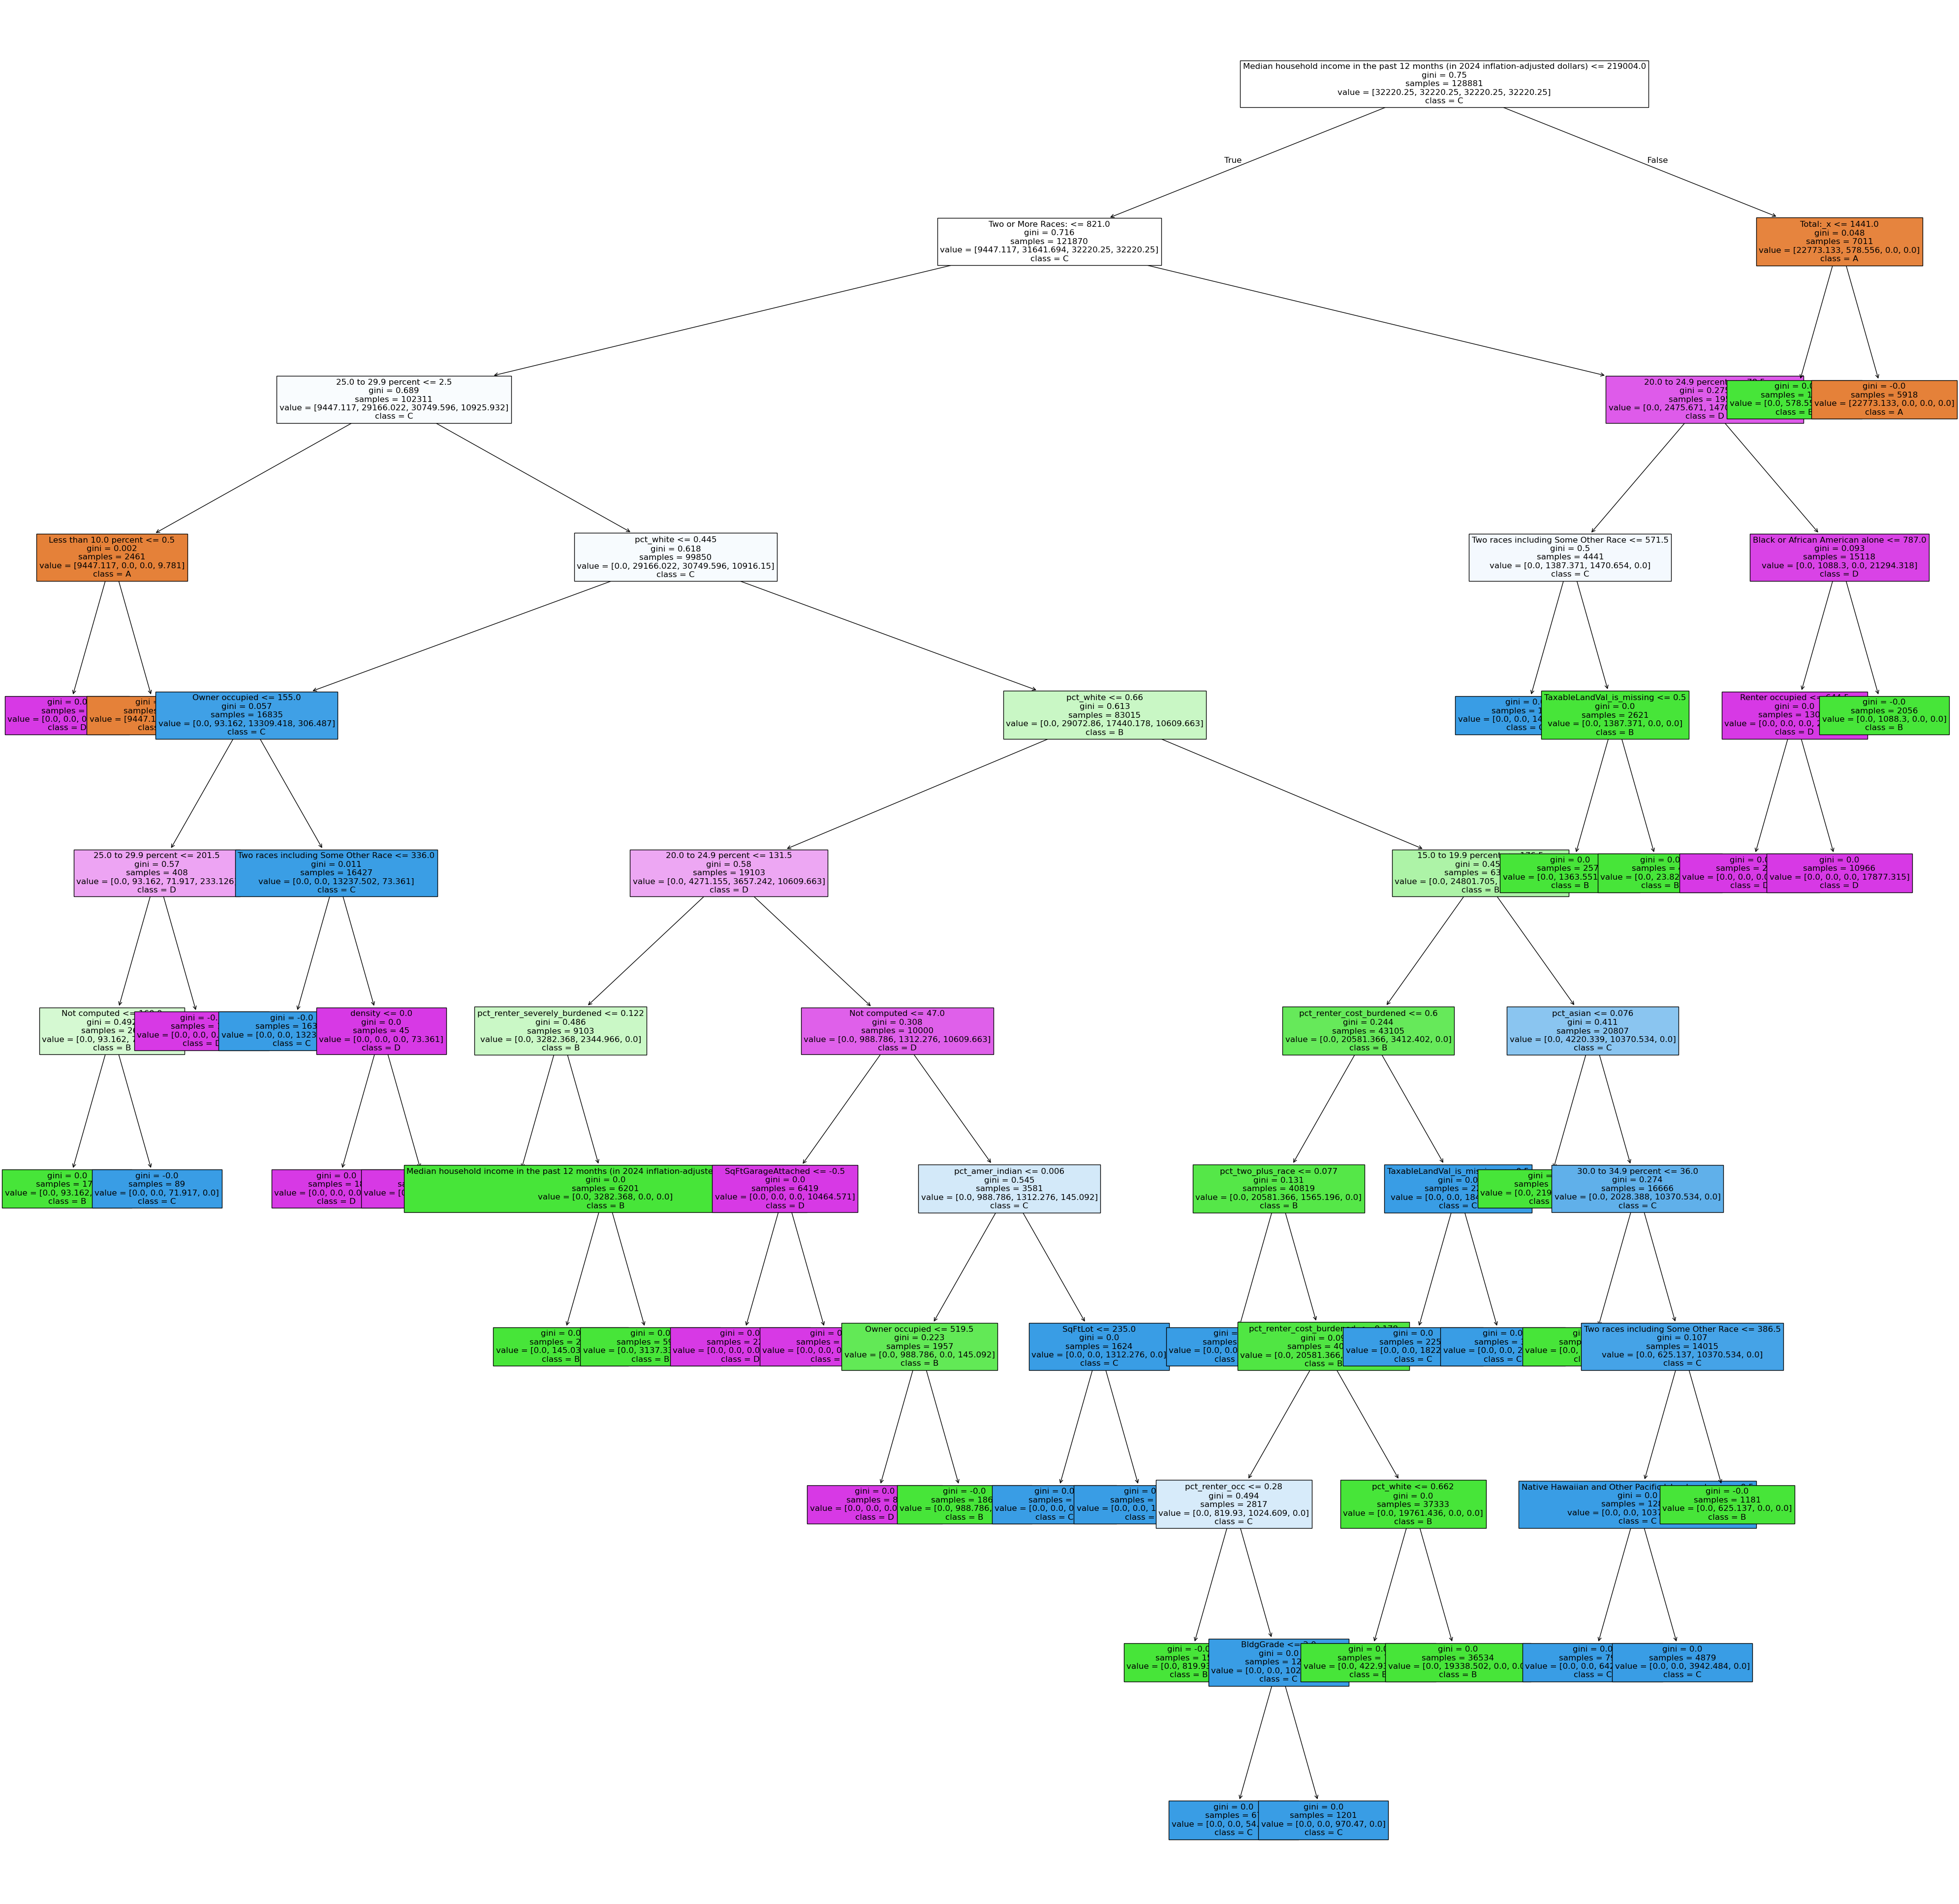

In [102]:
plt.figure(figsize=(50,50))
plot_tree(tree
          , filled=True
          , feature_names=X_train.columns
          , class_names=tree.classes_
          , label='all'
          , fontsize=12)
plt.show()

Create a confusion matrix.

In [85]:
# predict on test data
tree_pred = tree.predict(X_test)

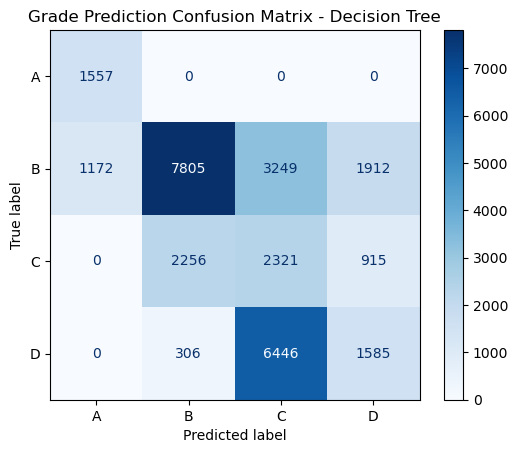

In [104]:
# Create a confusion matrix
cm_tree = confusion_matrix(y_test, tree_pred, labels = tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_tree, display_labels = tree.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Decision Tree")
plt.show()

In [86]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           A       0.57      1.00      0.73      1557
           B       0.75      0.55      0.64     14138
           C       0.19      0.42      0.27      5492
           D       0.36      0.19      0.25      8337

    accuracy                           0.45     29524
   macro avg       0.47      0.54      0.47     29524
weighted avg       0.53      0.45      0.46     29524



In [87]:
y_probs_tree = tree.predict_proba(X_test)

roc_auc_tree = roc_auc_score(y_test, y_probs_tree, multi_class="ovr")

print("ROC-AUC:", roc_auc_tree)

ROC-AUC: 0.6774395600713609


Prune the tree.

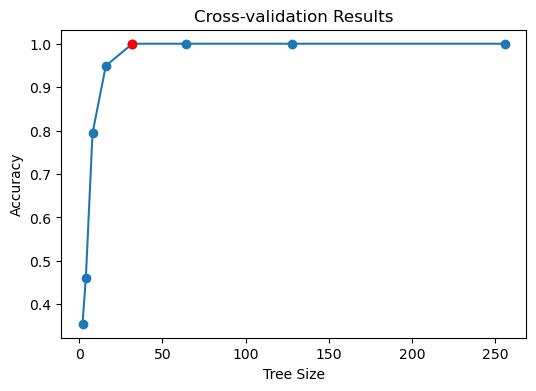

In [89]:
# cross-validation to determine optimal tree size
#params = {'max_leaf_nodes': range(2, 200, 5)}  
params = {'max_leaf_nodes': [2, 4, 8, 16, 32, 64, 128, 256]}
cv_tree = GridSearchCV(tree, params, cv=10)
cv_tree.fit(X_train, y_train)
cv_results = cv_tree.cv_results_

# find the best score for max leaf nodes
best_size = cv_tree.best_params_['max_leaf_nodes']
best_score = cv_tree.best_score_

# plot results of cross-validation
plt.figure(figsize=(6, 4))
plt.plot(cv_results["param_max_leaf_nodes"], cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

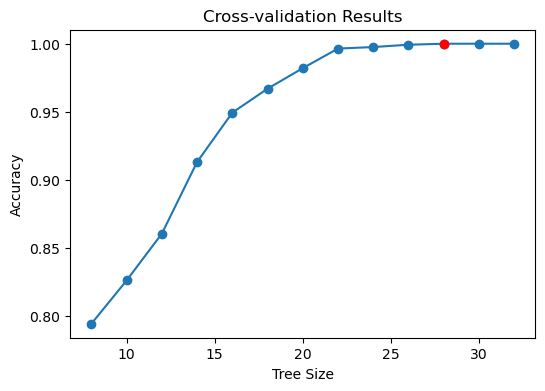

In [90]:
# cross-validation to determine optimal tree size, looking closer at elbow from above plot
#params = {'max_leaf_nodes': range(2, 200, 5)}  
params = {'max_leaf_nodes': range(8, 34, 2)}
cv_tree = GridSearchCV(tree, params, cv=10)
cv_tree.fit(X_train, y_train)
cv_results = cv_tree.cv_results_

# find the best score for max leaf nodes
best_size = cv_tree.best_params_['max_leaf_nodes']
best_score = cv_tree.best_score_

# plot results of cross-validation
plt.figure(figsize=(6, 4))
plt.plot(cv_results["param_max_leaf_nodes"], cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [91]:
# prune tree using optimal size
prune_tree = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=3)
prune_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,28
,min_impurity_decrease,0.0
,class_weight,None


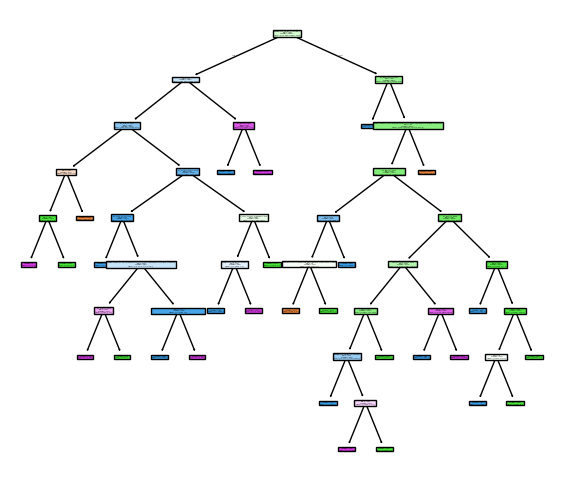

In [114]:
# plot pruned tree
plt.figure(figsize=(7,6))
plt.title('Pruned Tree')
plot_tree(prune_tree, feature_names=X_train.columns, filled=True);

In [94]:
# obtain predicted labels for test set
tree_pred2 = prune_tree.predict(X_test)

In [109]:
# create confusion matrix
confusion_matrix = pd.crosstab(index=tree_pred2, columns=y_test, rownames=[''])
print(confusion_matrix)

holc_dominant_grade     A     B     C     D
                                           
A                       0  1503     0     0
B                       0  8687  2256  2845
C                    1557  3948  2874  4267
D                       0     0   362  1225


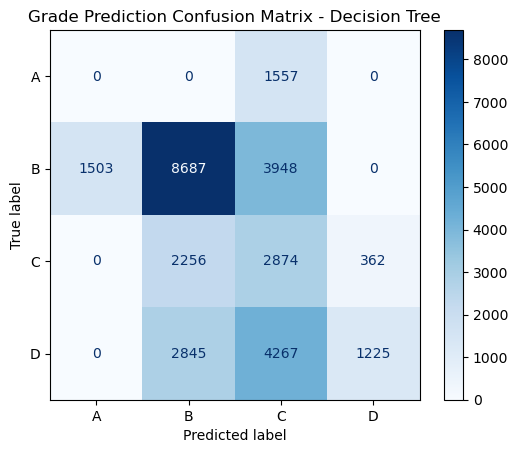

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Create a confusion matrix
cm_tree2 = confusion_matrix(y_test, tree_pred2, labels = tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_tree2, display_labels = tree.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Decision Tree")
plt.show()

In [92]:
# create a dataframe of feature importances and their corresponding column names
importances_tree2 = pd.DataFrame({'Feature': X_train.columns, 'Importance': prune_tree.feature_importances_})
importances_tree2 = importances_tree2.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_tree2)

                                              Feature  Importance
0                              Median value (dollars)    0.194407
1                                15.0 to 19.9 percent    0.116188
2                                           pct_black    0.109258
3                                  Two or More Races:    0.097666
4   Median household income in the past 12 months ...    0.084483
..                                                ...         ...
78                               40.0 to 49.9 percent    0.000000
79                                       Not computed    0.000000
80                                     NbrLivingUnits    0.000000
81                                    pct_amer_indian    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


In [95]:
print(classification_report(y_test, tree_pred2))

              precision    recall  f1-score   support

           A       0.00      0.00      0.00      1557
           B       0.63      0.61      0.62     14138
           C       0.23      0.52      0.32      5492
           D       0.77      0.15      0.25      8337

    accuracy                           0.43     29524
   macro avg       0.41      0.32      0.30     29524
weighted avg       0.56      0.43      0.43     29524



In [96]:
y_probs_tree2 = prune_tree.predict_proba(X_test)

roc_auc_tree2 = roc_auc_score(y_test, y_probs_tree2, multi_class="ovr")

print("ROC-AUC:", roc_auc_tree2)

ROC-AUC: 0.5594622248634095


Try an elbow value also.

In [97]:
# prune tree using optimal size based on elbow method
prune_tree2 = DecisionTreeClassifier(max_leaf_nodes=20, random_state=3)
prune_tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,20
,min_impurity_decrease,0.0
,class_weight,None


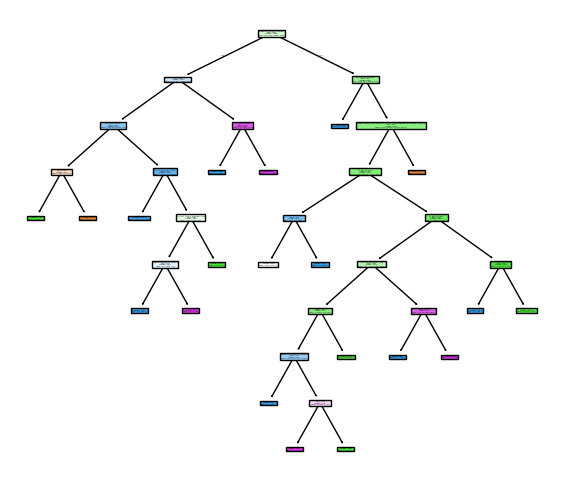

In [113]:
# plot pruned tree
plt.figure(figsize=(7,6))
plt.title('Pruned Tree')
plot_tree(prune_tree2, feature_names=X_train.columns, filled=True);

In [98]:
# obtain predicted labels for test set
tree_pred20 = prune_tree2.predict(X_test)

In [115]:
# create confusion matrix
cm20 = pd.crosstab(index=tree_pred20, columns=y_test, rownames=[''])
print(cm20)

holc_dominant_grade     A     B     C     D
                                           
A                       0  1503     0     0
B                       0  9782  2256  2653
C                    1557  2853  2874  4570
D                       0     0   362  1114


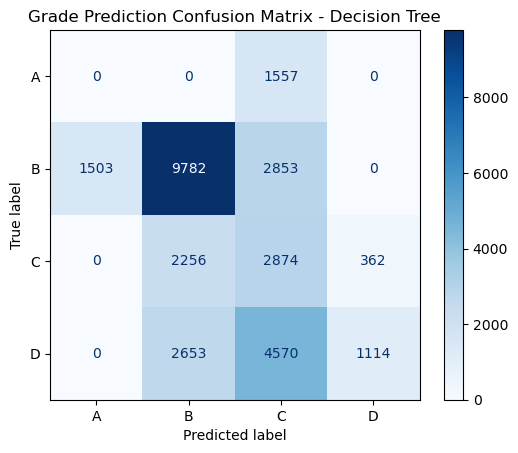

In [116]:
# Create a confusion matrix
cm_tree20 = confusion_matrix(y_test, tree_pred20, labels = tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_tree20, display_labels = tree.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - Decision Tree")
plt.show()

In [99]:
print(classification_report(y_test, tree_pred20))

              precision    recall  f1-score   support

           A       0.00      0.00      0.00      1557
           B       0.67      0.69      0.68     14138
           C       0.24      0.52      0.33      5492
           D       0.75      0.13      0.23      8337

    accuracy                           0.47     29524
   macro avg       0.42      0.34      0.31     29524
weighted avg       0.58      0.47      0.45     29524



In [100]:
y_probs_tree20 = prune_tree2.predict_proba(X_test)

roc_auc_tree20 = roc_auc_score(y_test, y_probs_tree20, multi_class="ovr")

print("ROC-AUC:", roc_auc_tree20)

ROC-AUC: 0.6052518310638068


In [101]:
# create a dataframe of feature importances and their corresponding column names
importances_tree20 = pd.DataFrame({'Feature': X_train.columns, 'Importance': prune_tree2.feature_importances_})
importances_tree20 = importances_tree20.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_tree20)

                                              Feature  Importance
0                              Median value (dollars)    0.209499
1                                15.0 to 19.9 percent    0.125208
2                                           pct_black    0.117739
3                                  Two or More Races:    0.105248
4   Median household income in the past 12 months ...    0.079963
..                                                ...         ...
78                Two races including Some Other Race    0.000000
79                              Some Other Race alone    0.000000
80   Native Hawaiian and Other Pacific Islander alone    0.000000
81                                        Asian alone    0.000000
82                                      is_industrial    0.000000

[83 rows x 2 columns]


#### Support Vector Model (Linear Kernel)

In [103]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [80]:
# fit SVM with linear kernel
svm_linear = SVC(kernel='linear', class_weight='balanced', max_iter=2000)

kfold = skm.KFold(5, random_state=0, shuffle=True)

grid_svm_linear = skm.GridSearchCV(svm_linear,
                        {'C':[0.01,0.1,1,5,10]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy',
                        n_jobs=-1)
grid_svm_linear.fit(X_train_scaled, y_train)
grid_svm_linear.best_params_

C:\Users\Veteran\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


{'C': 5}

In [81]:
best_svm_linear = grid_svm_linear.best_estimator_

# training error rate for linear kernel
y_pred_lin = best_svm_linear.predict(X_train_scaled)
training_error_lin = np.mean(y_pred_lin != y_train)

# test error rate for linear kernel
y_pred_test_lin = best_svm_linear.predict(X_test_scaled)
test_error_lin = np.mean(y_pred_test_lin != y_test)

print("Training error:", training_error_lin)
print("Test error:", test_error_lin)

Training error: 0.22505256787268876
Test error: 0.5590367158921555


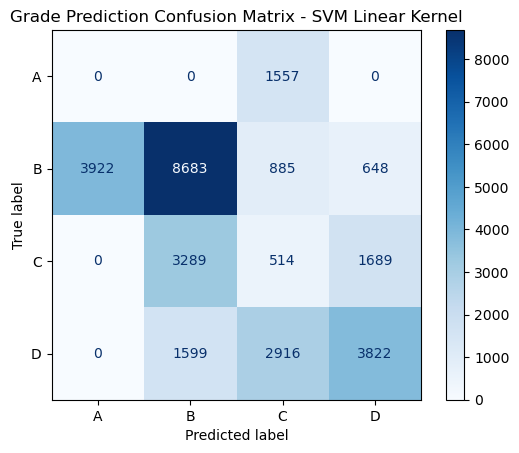

In [82]:
# Create a confusion matrix
cm_svm_linear = confusion_matrix(y_test, y_pred_test_lin, labels = best_svm_linear.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm_linear, display_labels = best_svm_linear.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - SVM Linear Kernel")
plt.show()

#### Support Vector Model (Radial Kernel)

Prior to applying the radial and polynomial models, a subset of the training data (20,000) observations is used to train the models in order to avoid excessively long runtimes.

In [104]:
# taking subsample of training data to perform hyperparameter tuning
X_train_sample = X_train_scaled.sample(n=20000, random_state=3)
y_train_sample = y_train.loc[X_train_sample.index]

KeyError: '[72184, 123023, 70698, 20699, 128483, 98254, 124789, 45444, 43403, 8751, 126037, 58511, 95378, 7127, 49957, 7381, 102361, 46288, 118903, 88200, 31803, 91112, 104415, 33483, 111572, 52950, 69435, 25486, 22366, 100005, 125841, 84801, 23092, 75015, 116747, 56724, 53834, 108784, 8006, 46855, 126358, 37965, 45437, 111305, 79622, 113243, 123056, 18670, 94726, 22956, 1528, 5698, 31608, 6238, 94431, 31543, 19477, 43300, 116931, 9515, 56930, 72563, 18424, 22246, 124750, 64346, 123081, 19897, 15704, 30943, 82680, 6253, 12128, 84997, 103891, 19429, 87514, 46538, 104058, 76242, 102570, 62720, 8849, 121573, 55563, 5605, 24168, 10015, 89043, 63360, 789, 13314, 43178, 112383, 32160, 98777, 124728, 126920, 109362, 1660, 57953, 85126, 123158, 123761, 7702, 28854, 127012, 68278, 91180, 107245, 104140, 98572, 86017, 99945, 102538, 95774, 97726, 30042, 101241, 30255, 80590, 105528, 126550, 40007, 115509, 84489, 93748, 47690, 52405, 78616, 63010, 82110, 84854, 83886, 24865, 6686, 41216, 49241, 655, 30707, 121550, 12508, 84574, 1531, 16019, 78729, 9466, 77593, 77115, 111812, 76526, 15988, 2644, 30510, 119945, 18383, 21840, 125810, 20480, 82186, 55327, 36230, 85813, 46593, 55003, 122135, 73813, 121749, 116448, 24456, 116794, 112922, 82519, 69441, 80000, 39782, 34472, 24332, 121442, 81900, 77202, 24228, 25715, 94109, 83444, 29365, 112720, 84119, 19320, 88132, 31060, 107138, 1498, 65364, 2288, 22372, 51085, 46483, 58317, 111796, 30040, 10165, 38102, 16736, 42971, 19024, 36054, 31743, 88125, 106375, 16686, 86998, 56090, 17890, 73284, 121881, 77414, 10949, 50555, 16871, 33688, 7125, 124603, 115468, 89215, 21835, 73148, 22914, 120732, 48941, 81867, 92911, 84581, 38427, 82506, 31914, 49812, 78328, 11088, 9945, 45745, 6974, 46765, 19218, 32419, 111908, 53820, 105163, 55741, 121826, 39844, 115839, 89036, 99660, 24328, 50450, 76073, 27870, 14606, 6572, 117880, 99820, 16529, 118804, 1599, 119342, 27967, 21236, 74937, 56109, 80207, 97060, 77113, 42019, 36349, 81935, 56246, 48677, 13175, 119099, 113695, 60400, 21410, 61594, 128489, 46868, 21113, 61075, 78822, 70458, 38677, 95414, 54785, 109507, 82464, 14307, 61666, 56995, 86349, 113492, 112567, 78138, 83568, 98877, 103189, 43473, 71511, 86182, 109295, 11137, 67099, 92651, 103643, 37522, 31809, 23237, 123702, 116271, 2114, 18635, 19018, 29065, 13201, 108452, 4872, 46662, 104716, 23028, 42597, 101766, 68640, 55795, 52214, 105978, 11316, 127941, 101392, 78649, 47902, 68892, 99997, 45050, 17567, 53545, 119086, 52369, 55749, 20475, 111384, 118786, 49016, 67706, 14932, 74333, 51527, 19677, 44548, 84898, 6383, 80413, 3408, 69096, 104086, 39027, 29153, 57815, 108290, 81898, 9819, 22005, 82715, 87806, 114430, 15901, 41087, 107558, 93095, 107313, 123395, 95291, 25882, 13990, 42369, 68376, 71462, 52742, 15936, 66217, 35279, 97973, 107321, 43045, 127377, 102382, 99357, 120616, 65489, 112366, 116979, 26420, 74229, 18204, 35820, 24121, 37468, 117321, 83308, 43987, 127921, 316, 2088, 66584, 93435, 45488, 96462, 77840, 95119, 40572, 106143, 85399, 73, 95672, 54098, 26965, 91051, 31728, 127227, 109708, 61484, 120140, 52983, 39271, 99757, 57040, 22241, 105542, 26541, 91739, 126671, 75109, 126907, 112128, 71773, 97496, 73987, 87544, 36832, 78937, 108011, 117660, 108267, 17452, 126339, 3095, 23541, 118066, 10083, 103266, 117400, 4445, 107125, 40066, 104845, 67636, 55916, 65137, 50742, 31505, 80303, 106287, 107366, 75327, 38863, 5143, 31669, 83401, 118006, 37093, 79581, 92722, 76961, 29592, 77250, 33670, 22685, 38955, 20462, 79715, 31108, 90266, 74623, 80569, 56756, 28126, 49757, 28267, 92377, 45575, 103579, 35331, 124532, 34868, 121244, 115864, 40110, 5214, 76476, 26615, 61070, 102127, 41307, 120021, 42556, 51722, 106176, 107386, 3358, 33391, 88341, 84632, 55693, 62216, 49775, 108345, 43815, 22576, 123803, 64446, 127360, 43199, 96243, 85377, 119066, 2283, 44663, 29311, 60017, 35700, 50202, 51376, 1712, 60223, 85396, 7748, 13233, 99208, 65511, 50888, 73991, 117715, 34552, 67450, 25604, 540, 75701, 42216, 26000, 81822, 14085, 117603, 37623, 117869, 39724, 114892, 1246, 46430, 125236, 30539, 81607, 103044, 127661, 362, 75264, 127281, 99821, 121197, 106257, 44289, 123532, 65543, 74614, 1686, 58728, 128616, 27776, 89851, 21957, 111040, 94844, 37705, 44684, 35236, 26349, 737, 107116, 42228, 53286, 82836, 35493, 35510, 35874, 28260, 50832, 118901, 80320, 43613, 23462, 33623, 74918, 30097, 75532, 24060, 75816, 2243, 120506, 5937, 42552, 17309, 13737, 13549, 23359, 65686, 121121, 40360, 17854, 52825, 60706, 54300, 86121, 126619, 94841, 50773, 67332, 118719, 25385, 98409, 85959, 16117, 102385, 1846, 64877, 77947, 23750, 5832, 29021, 65464, 119411, 89368, 25456, 123053, 110014, 85602, 123140, 91215, 101948, 57878, 118808, 122888, 72758, 69643, 76848, 35335, 128403, 67872, 15107, 73644, 120156, 55743, 3020, 93274, 28451, 25813, 21118, 71122, 2567, 82745, 117533, 85308, 75174, 34307, 29512, 30192, 33756, 89749, 4769, 205, 48239, 123469, 45599, 69844, 98527, 127771, 99303, 56020, 22155, 39372, 108380, 38303, 101679, 32002, 29674, 128161, 122413, 16305, 105703, 80786, 124747, 14319, 23402, 72131, 22166, 2701, 67178, 116004, 101677, 108453, 104107, 91836, 98248, 48994, 74076, 106665, 3818, 87812, 125202, 38517, 763, 60074, 38836, 87174, 29589, 55973, 128319, 126537, 80832, 106683, 2751, 55499, 2307, 28022, 57904, 114627, 58191, 106463, 79296, 123460, 12184, 18761, 42120, 50029, 5607, 117613, 77722, 105053, 119524, 8839, 71381, 52420, 10760, 51264, 52442, 54068, 85405, 126426, 56034, 86506, 98782, 62150, 101761, 60221, 75037, 69599, 23313, 14650, 71910, 92006, 15057, 29256, 61951, 106729, 30846, 61688, 60385, 77071, 16110, 39354, 107188, 29281, 115790, 12548, 82337, 11247, 2668, 34882, 107129, 92736, 21146, 69140, 10033, 88613, 3194, 25150, 23628, 57567, 43933, 78796, 30918, 45347, 82354, 88711, 111364, 116666, 75312, 14888, 77741, 18514, 111458, 36283, 114928, 25586, 88002, 21276, 119200, 114860, 32642, 37105, 31424, 65599, 112536, 75497, 73332, 117352, 68563, 17133, 9404, 53804, 81118, 39000, 41727, 89947, 109595, 64913, 82859, 116687, 125259, 44107, 102829, 77577, 119399, 58454, 113068, 59911, 41266, 122272, 27130, 40847, 106308, 2395, 14638, 78698, 19977, 82266, 15911, 123306, 22517, 50719, 10707, 95660, 107317, 33354, 14921, 55963, 83786, 22600, 126965, 35907, 33304, 95200, 128006, 102952, 110187, 117181, 12295, 54826, 8009, 18660, 63822, 105787, 98916, 127699, 91008, 35519, 85461, 20306, 67208, 77575, 86663, 91372, 49514, 90091, 17561, 82158, 13614, 1490, 14269, 57059, 38284, 50446, 4472, 9886, 34023, 46771, 83899, 30759, 108922, 62789, 18925, 60628, 73498, 38503, 102254, 45015, 89024, 93774, 36143, 69820, 88316, 116681, 44683, 46740, 81973, 56296, 60483, 71275, 75005, 42804, 25237, 31779, 42777, 79555, 124102, 34627, 50069, 97378, 106211, 77411, 62392, 127938, 98583, 90897, 71026, 76582, 65598, 72035, 126097, 91107, 108272, 117733, 105641, 62512, 37322, 39322, 34535, 101371, 90500, 26504, 51782, 120660, 58789, 88772, 31123, 22375, 120340, 8993, 12473, 106340, 78056, 92951, 81678, 112285, 18767, 122176, 71203, 39622, 110381, 116380, 31558, 56341, 80671, 116594, 118129, 25011, 83880, 56767, 70081, 94506, 55464, 56105, 1981, 73188, 19142, 82399, 13319, 14088, 101189, 109233, 21029, 112983, 60183, 97518, 102821, 21207, 89849, 19135, 26100, 28941, 113080, 87359, 4399, 45853, 40803, 125994, 48643, 54416, 41722, 49612, 118227, 56522, 113147, 31350, 59759, 40527, 7823, 10129, 32678, 96912, 3677, 42354, 69484, 1768, 94510, 36021, 17804, 78903, 64442, 79869, 40990, 69035, 59155, 73209, 99260, 99680, 126881, 40793, 95344, 3975, 25218, 126135, 95952, 52306, 60935, 1633, 2162, 113585, 71966, 102903, 44460, 48180, 114366, 97781, 85075, 71429, 103413, 101802, 113070, 58338, 28150, 71716, 12439, 17725, 119783, 24293, 17946, 97124, 24408, 42347, 90198, 121071, 23278, 86543, 41775, 108136, 30529, 48624, 54014, 30320, 64566, 100796, 106142, 75582, 2416, 72192, 20749, 128023, 126477, 14205, 11133, 68459, 90331, 70080, 123115, 66370, 47703, 77944, 75468, 50197, 15156, 116222, 50090, 62880, 27819, 105480, 83665, 67233, 51218, 43134, 62129, 39424, 64563, 77091, 37109, 39769, 115777, 115575, 46547, 67293, 15835, 86955, 120123, 94625, 55591, 43097, 125334, 43415, 97314, 39075, 90487, 64850, 88541, 54953, 71524, 38476, 110061, 8430, 24892, 19941, 9838, 38553, 78734, 121523, 16947, 41583, 111118, 21901, 23147, 26436, 39832, 2172, 94030, 102751, 741, 73781, 89138, 104825, 85588, 29703, 30232, 95343, 18060, 118324, 124027, 126211, 16983, 111982, 17856, 18605, 875, 13070, 117038, 75839, 94721, 55646, 14364, 23479, 93438, 73241, 59590, 102146, 6916, 44364, 28948, 3634, 29399, 125623, 66643, 90740, 40217, 91074, 50816, 68180, 36362, 109332, 28394, 35371, 7341, 127538, 24374, 19010, 49218, 34392, 92600, 109, 114586, 101578, 60913, 122401, 49925, 2544, 22426, 98357, 123044, 46819, 25636, 109985, 69547, 2961, 106884, 82796, 101506, 43262, 866, 40635, 98542, 43828, 73178, 116513, 87118, 18770, 60567, 52483, 109479, 93108, 9678, 97468, 23086, 41082, 13084, 71976, 13205, 32907, 16627, 17588, 62314, 26524, 101997, 88461, 71328, 60038, 29848, 49349, 23522, 73060, 101935, 115806, 104191, 68580, 50248, 23530, 57858, 38348, 46224, 86921, 45028, 124369, 41971, 86950, 58752, 9761, 73487, 84697, 91021, 84788, 122158, 54138, 126898, 87241, 34435, 112837, 61039, 107676, 121124, 3858, 56824, 5894, 122749, 126841, 34278, 127289, 55151, 66321, 16690, 57488, 57995, 91474, 24016, 40571, 28409, 6138, 73736, 39046, 40103, 44769, 854, 122709, 25447, 32178, 71457, 66241, 63109, 118962, 124820, 43657, 117970, 95883, 43724, 104106, 42620, 125111, 19348, 42179, 4974, 115799, 60932, 64449, 43751, 5282, 120649, 72222, 120409, 13769, 62261, 55054, 90936, 18834, 42149, 65056, 11883, 22189, 23168, 37345, 25108, 94674, 107583, 85887, 49627, 71309, 68370, 105019, 30090, 17837, 40065, 65827, 114258, 64511, 63559, 87700, 116125, 2079, 103585, 122370, 83928, 117976, 86615, 58866, 122262, 30991, 18933, 21141, 83272, 72027, 113063, 113470, 116862, 73911, 49857, 67576, 37768, 79680, 20020, 71062, 79713, 45020, 36195, 7208, 48637, 12970, 15128, 92874, 105789, 106879, 108522, 104575, 41981, 31544, 42984, 12477, 66669, 86581, 467, 95169, 84593, 8224, 118217, 71565, 123333, 122441, 34400, 30024, 123446, 34393, 93836, 4449, 62613, 38046, 119346, 4529, 21523, 119699, 85699, 124766, 68173, 77551, 63288, 122163, 88262, 67001, 58018, 24061, 60762, 12368, 123591, 52661, 69972, 38211, 86163, 61813, 62538, 33313, 10167, 126565, 88166, 102746, 3548, 125270, 18618, 57696, 11840, 68769, 79601, 121977, 4242, 64058, 84831, 75115, 120798, 83566, 22061, 1896, 1352, 62344, 31792, 66049, 72813, 26989, 92008, 116580, 59553, 31280, 12829, 6367, 8767, 35814, 110208, 42913, 17151, 86147, 67660, 97265, 119267, 116771, 96586, 62964, 61389, 4808, 111313, 120320, 64914, 17693, 85802, 19196, 51864, 54945, 64553, 79168, 51455, 4475, 82075, 87321, 4944, 3269, 35472, 2883, 9030, 1005, 101589, 24375, 48857, 1863, 63993, 101908, 12886, 5114, 39207, 110647, 72108, 92260, 5772, 70704, 96858, 44489, 31761, 38831, 5298, 95585, 78239, 28112, 35151, 121351, 92239, 16675, 36347, 111993, 87265, 109613, 89667, 28850, 38159, 120980, 26101, 14236, 70919, 6541, 115183, 21748, 101404, 24671, 103994, 116899, 76604, 86717, 5154, 8177, 5121, 105723, 49703, 76153, 56755, 16516, 4995, 124022, 55096, 100288, 96347, 30306, 34910, 14387, 123850, 11339, 88754, 36674, 113998, 47517, 62445, 54372, 88991, 87122, 52253, 10195, 109712, 92624, 117151, 58853, 98875, 74295, 82283, 117338, 51833, 26152, 58686, 10588, 106689, 30309, 36086, 87775, 98150, 62681, 39014, 112392, 17178, 98894, 89779, 40169, 107551, 77151, 97944, 21852, 95903, 79824, 79314, 49576, 120374, 28453, 46046, 20741, 125267, 41519, 27453, 34087, 35757, 5365, 1109, 81592, 30250, 116719, 69634, 66294, 54015, 78795, 116884, 39621, 70434, 99104, 126084, 5118, 65104, 30996, 69121, 84466, 7503, 123540, 82714, 88583, 87761, 87374, 61707, 53038, 4666, 85581, 102182, 54012, 18520, 112298, 2350, 2269, 99858, 43170, 27867, 91736, 104360, 68826, 105583, 6055, 38557, 89702, 46872, 118051, 84480, 95488, 41832, 69651, 108326, 64323, 53097, 10929, 52099, 39410, 21174, 32738, 87508, 23309, 17232, 116417, 97794, 29043, 19864, 118381, 45114, 23052, 105214, 27100, 10608, 63285, 73275, 100427, 43855, 123108, 70143, 71766, 108910, 104214, 27307, 65512, 29671, 54615, 88529, 59212, 40836, 81759, 6911, 31121, 33132, 22305, 55274, 57670, 104281, 895, 116469, 56877, 104003, 103707, 35310, 82204, 28342, 21278, 16893, 7965, 46937, 3409, 30881, 75776, 8394, 127889, 2000, 36660, 72618, 27425, 22583, 53313, 77595, 118005, 54855, 98847, 106234, 112199, 46240, 43352, 4452, 116576, 9705, 45588, 6901, 81227, 72960, 69000, 32284, 111042, 50366, 126455, 77512, 79984, 84173, 77110, 85622, 8067, 76375, 1080, 120532, 55421, 43895, 9141, 77216, 32620, 5830, 1733, 48267, 126046, 69759, 85028, 26621, 89766, 67274, 123829, 7540, 55095, 45807, 85237, 17216, 50775, 25417, 50560, 65697, 10945, 104596, 101337, 91078, 34822, 65182, 14178, 94450, 77231, 40349, 62995, 49047, 32694, 108381, 127424, 76917, 66671, 5389, 27968, 51958, 65474, 119610, 82166, 110799, 91770, 52548, 84210, 86903, 128821, 76811, 52268, 50559, 54501, 122039, 47081, 47075, 11371, 5777, 19379, 50720, 54402, 54641, 64371, 22568, 45343, 106368, 55739, 114688, 89203, 10085, 66138, 5752, 50898, 124936, 6433, 63888, 86826, 35274, 64234, 40839, 48268, 123325, 63893, 11776, 30528, 125754, 64952, 64852, 102050, 17766, 45391, 77472, 63823, 110938, 86942, 58961, 31402, 38036, 11095, 128390, 121067, 97355, 86072, 7192, 102041, 39491, 14540, 85274, 594, 120054, 33178, 87480, 107400, 2969, 71483, 93315, 119685, 116863, 112371, 50165, 91866, 86714, 83955, 47369, 49312, 116636, 19740, 48342, 2640, 24644, 110688, 59591, 78088, 106958, 39878, 19647, 54653, 116972, 10257, 21456, 58962, 122840, 44156, 79674, 28742, 42127, 1773, 115420, 15072, 87995, 106712, 25247, 106520, 40723, 30313, 87842, 49858, 104824, 74286, 123905, 122523, 57172, 20894, 89310, 84462, 50465, 105167, 16458, 52942, 89982, 29151, 27708, 434, 97622, 112077, 11851, 48104, 53771, 120581, 80206, 12526, 28332, 94551, 127922, 54055, 37206, 45130, 38813, 87425, 68139, 13648, 49006, 21664, 124754, 56515, 85657, 100127, 105954, 67112, 47886, 56980, 67959, 82051, 104472, 45828, 116085, 62486, 36728, 10188, 103956, 53244, 90730, 119451, 78762, 53477, 106545, 60617, 51439, 61958, 45776, 115857, 96590, 58529, 39411, 11262, 97777, 91605, 47458, 56891, 22149, 87925, 74679, 62814, 56214, 60061, 61512, 98838, 32246, 14768, 84996, 121286, 11967, 11870, 81213, 103739, 40892, 6779, 119006, 10527, 86473, 99951, 95284, 74347, 86512, 86126, 15883, 46408, 13119, 42816, 16006, 67073, 119351, 39723, 9484, 63427, 51132, 1045, 118510, 48172, 13104, 87186, 58987, 5383, 112608, 124130, 45730, 88875, 40882, 12531, 85789, 56956, 123112, 49438, 8119, 33702, 24011, 4744, 89918, 35958, 79961, 52035, 86480, 21126, 55245, 53769, 112833, 109448, 8597, 128809, 44960, 79892, 61518, 118660, 893, 85942, 113457, 81979, 83843, 34742, 30493, 56144, 115826, 21503, 68234, 70695, 86860, 67039, 12706, 77073, 21682, 38961, 110285, 16400, 18357, 54152, 90643, 25709, 116114, 101161, 72853, 125424, 95680, 49023, 71481, 19418, 7290, 127465, 70211, 50343, 114727, 33398, 5378, 57732, 44784, 2612, 34532, 81559, 18423, 29140, 86230, 88914, 44560, 29033, 30933, 38216, 12318, 39426, 27953, 8514, 10683, 83260, 4985, 67696, 44329, 30277, 10428, 74690, 110712, 53414, 48880, 125619, 25560, 77101, 113937, 111997, 44300, 34096, 6348, 34889, 32992, 42220, 15913, 58823, 119778, 82483, 60676, 15139, 99320, 73038, 115432, 6859, 48822, 21632, 127031, 54060, 68983, 117204, 81275, 74670, 2804, 74343, 95979, 124799, 57218, 34762, 68717, 23634, 120020, 4253, 121087, 101517, 112835, 88254, 29455, 73206, 7714, 105318, 86093, 115820, 116444, 96806, 97175, 82014, 95643, 109726, 71077, 50135, 92748, 40470, 42723, 105756, 109216, 89132, 102258, 77236, 90784, 39945, 107065, 86279, 12753, 82670, 117490, 79597, 3693, 4971, 95972, 34766, 28297, 70502, 47030, 111603, 46857, 1615, 84404, 70484, 68074, 17180, 108113, 26213, 100589, 72463, 103877, 27937, 90575, 126732, 8102, 22850, 65922, 2556, 59584, 41702, 60683, 12952, 50548, 91763, 112739, 116445, 114600, 73687, 39125, 21697, 36324, 33763, 760, 38856, 108295, 99395, 12700, 64043, 25845, 119998, 9723, 89062, 16904, 69900, 1744, 11625, 125031, 76540, 14979, 126522, 67487, 32701, 107659, 35378, 63928, 104643, 1926, 59135, 32317, 20404, 85585, 65103, 114562, 103977, 58982, 122973, 120550, 102074, 68615, 23563, 127332, 19388, 102067, 28119, 72187, 105225, 13331, 35256, 3585, 102681, 63864, 11021, 67633, 6381, 45921, 17269, 120834, 54343, 48737, 38261, 70438, 20319, 5570, 40319, 33389, 121820, 92792, 76455, 4000, 45176, 89603, 114227, 99364, 66715, 120249, 14305, 78895, 83249, 88299, 123947, 49778, 53976, 1206, 55855, 91632, 103258, 28943, 1159, 128490, 46891, 95971, 118695, 82571, 34805, 55815, 19700, 96080, 21123, 114299, 18724, 17110, 69835, 112410, 122856, 122462, 14897, 69495, 16668, 12471, 13783, 29541, 87427, 105121, 68794, 104908, 74618, 45651, 47475, 91296, 2831, 30265, 26092, 99844, 94545, 10023, 6857, 64186, 34926, 37516, 8516, 50963, 58684, 59035, 46453, 99174, 42089, 85262, 118581, 113995, 97381, 8429, 72811, 2020, 90048, 70949, 87688, 9276, 95052, 50205, 40309, 118115, 12997, 99758, 59657, 44702, 9507, 57035, 98005, 77027, 40817, 128198, 117847, 54017, 112865, 21821, 114364, 14175, 67325, 85104, 15142, 76874, 71665, 125110, 17129, 12191, 37422, 113376, 106522, 60368, 44970, 39335, 36969, 81452, 107177, 102662, 115876, 69109, 110363, 59219, 23497, 10800, 61520, 60022, 47490, 33079, 96338, 112243, 4709, 84474, 30168, 115238, 65699, 52648, 98356, 76617, 53815, 62300, 97515, 107303, 36838, 119226, 47620, 48105, 44004, 97088, 36886, 3019, 122134, 8318, 9449, 61338, 2610, 115747, 65508, 30275, 9494, 104746, 27062, 56588, 118869, 61279, 71606, 120102, 74099, 84304, 116236, 118030, 2767, 23779, 109765, 97994, 46751, 71361, 40515, 35675, 70660, 15420, 102197, 46047, 46804, 65146, 34734, 19678, 9591, 127150, 120910, 24109, 76760, 5068, 41855, 103145, 56856, 44052, 79645, 86605, 93237, 7375, 26784, 8802, 38058, 1642, 97012, 50120, 42451, 119459, 16283, 83469, 40398, 14774, 49937, 23571, 3055, 79332, 19720, 56911, 20855, 28176, 45974, 79019, 42845, 2117, 40373, 13159, 120829, 26752, 55995, 39881, 49145, 13309, 21018, 118093, 69442, 20022, 36761, 70617, 102711, 12144, 127844, 21115, 45848, 31014, 34356, 65296, 37666, 57076, 116525, 125976, 72363, 40893, 73932, 127246, 122820, 79663, 13455, 91970, 90786, 121600, 107616, 19509, 34891, 18559, 73933, 14295, 50824, 39511, 120899, 33430, 103960, 81500, 100033, 98145, 20375, 113882, 76169, 2579, 107907, 102090, 64460, 95681, 109823, 127292, 29453, 94898, 9367, 78411, 12583, 86181, 119698, 127469, 39025, 12480, 4544, 104387, 83703, 17863, 78840, 44616, 24224, 30867, 36670, 38054, 193, 71030, 48780, 60172, 122923, 46752, 61311, 72510, 122899, 86957, 16597, 82391, 1133, 61881, 103592, 44553, 26299, 120478, 30464, 68877, 106673, 116730, 52261, 4573, 82661, 111299, 35066, 86386, 3331, 37906, 75606, 60979, 65536, 115508, 53856, 53891, 66179, 106796, 126128, 66762, 100194, 46331, 28431, 6275, 127845, 120936, 87281, 102774, 65147, 65732, 10125, 135, 69525, 29858, 73634, 120900, 67006, 109169, 114672, 42553, 99642, 38911, 44592, 95406, 17074, 18863, 84430, 90480, 73939, 68657, 31787, 71076, 43355, 81831, 49816, 93324, 17552, 23014, 107031, 67963, 5005, 105892, 69744, 72675, 72615, 128532, 6717, 11065, 22022, 11581, 11517, 79159, 109981, 1421, 92940, 58781, 54799, 91358, 92409, 126258, 123046, 1953, 125750, 123069, 28254, 109193, 50638, 121978, 1784, 63287, 79711, 96889, 14448, 8638, 7408, 13768, 80933, 119917, 28558, 82011, 95201, 120818, 107582, 124811, 117205, 45676, 87133, 63674, 46604, 106765, 51849, 75436, 66703, 36271, 47457, 61302, 73827, 3066, 10007, 85002, 40479, 115467, 36246, 1708, 11474, 14094, 88986, 118773, 118457, 111351, 76272, 75551, 50082, 81451, 5371, 12888, 66305, 43129, 79419, 114842, 38336, 127490, 75267, 37766, 49544, 1289, 87564, 53245, 97456, 42033, 1477, 127678, 1959, 109006, 74233, 85350, 48678, 56413, 64313, 21399, 86148, 92348, 104592, 118394, 52210, 51574, 74817, 32462, 2581, 58624, 26867, 74541, 45148, 123945, 61391, 18721, 11488, 22105, 13679, 43308, 23749, 20789, 123682, 21096, 127961, 11543, 21534, 118894, 110359, 43753, 30297, 96494, 53691, 57612, 104560, 11340, 101286, 66300, 26584, 92346, 117428, 8568, 27827, 87639, 83079, 89809, 105201, 53582, 63283, 101878, 29776, 86459, 114271, 1238, 122483, 83212, 54875, 64881, 10300, 33475, 75545, 127756, 101840, 47053, 58760, 78007, 34844, 7567, 27430, 104206, 15482, 100281, 50378, 122234, 96551, 71970, 89420, 1314, 118395, 62775, 28942, 8647, 45995, 50854, 15979, 67823, 117492, 35369, 62185, 60188, 46678, 121184, 107155, 102583, 39478, 55400, 127577, 101391, 90024, 122301, 23446, 95242, 24775, 112443, 121086, 10005, 116145, 98247, 39800, 54650, 124577, 25903, 21059, 44412, 100422, 94780, 32796, 121716, 41085, 86431, 23187, 15724, 28719, 74617, 67973, 74639, 199, 117571, 96698, 39442, 93271, 60010, 126759, 80575, 12907, 81043, 84827, 95082, 25826, 51983, 51408, 93989, 109394, 67152, 95274, 34998, 117741, 29507, 63979, 115389, 89634, 92758, 29832, 16550, 47133, 55632, 108720, 88015, 23804, 116915, 18292, 28820, 119612, 12981, 126605, 68483, 33488, 123548, 19667, 2524, 98278, 26519, 107903, 54386, 54924, 87116, 98852, 13304, 107236, 80785, 36835, 98594, 5799, 98947, 44064, 35904, 85023, 40704, 56056, 105335, 55841, 11167, 77327, 7376, 67949, 80704, 106012, 14288, 22228, 70039, 41167, 89315, 539, 91819, 121587, 34295, 10959, 22476, 91861, 1961, 3598, 15582, 78323, 12393, 122519, 37183, 45197, 83807, 71282, 63416, 27737, 42308, 32693, 116583, 3178, 64202, 70907, 98549, 6088, 87385, 86046, 38214, 69199, 126127, 45553, 50569, 58331, 47728, 87774, 103991, 117203, 94336, 114313, 112357, 25863, 92332, 14393, 116252, 64705, 72171, 96727, 120260, 31482, 92590, 115569, 78578, 24142, 47744, 40639, 59028, 124910, 124845, 75373, 22753, 118493, 53715, 45263, 90167, 64345, 103966, 108695, 88837, 64146, 30225, 8373, 75000, 67754, 91690, 21004, 53322, 84884, 5562, 85024, 68637, 87912, 55349, 26492, 29409, 73011, 24155, 14620, 86514, 75149, 21859, 68111, 108410, 116519, 68378, 25597, 71340, 87836, 115599, 5500, 97814, 90368, 56674, 94815, 85129, 26425, 75604, 74897, 5233, 114357, 59218, 126944, 55938, 94852, 43295, 2662, 2964, 54738, 83520, 66789, 17878, 120849, 24078, 101859, 28783, 30091, 79503, 37546, 2936, 32891, 17298, 27839, 47977, 124294, 55730, 91392, 21161, 96094, 9702, 4729, 13793, 11296, 16692, 54341, 16318, 79735, 70090, 477, 36379, 15271, 20491, 127003, 13399, 109488, 71752, 105860, 125652, 58615, 88482, 114283, 103470, 5266, 92451, 96169, 48685, 68054, 103069, 43038, 76431, 11878, 118703, 40681, 13839, 24978, 8538, 101702, 128684, 90613, 40928, 113931, 60313, 3094, 84554, 79710, 98607, 42682, 78521, 25933, 105326, 48037, 83645, 59893, 44631, 82739, 47633, 29515, 95188, 28481, 44451, 118174, 73775, 84460, 115773, 99886, 72907, 65653, 23106, 21176, 9551, 18665, 30156, 55227, 41462, 115498, 6270, 127825, 63526, 17790, 92301, 22821, 36772, 99988, 122082, 14574, 27925, 58897, 65183, 50825, 55139, 114123, 97000, 44435, 108962, 107969, 1147, 80822, 44218, 106523, 63063, 21702, 59171, 5520, 24392, 19685, 113850, 34596, 37357, 30100, 5790, 101669, 127191, 13422, 63859, 67528, 89207, 69725, 95905, 67844, 30607, 39157, 35283, 79958, 57733, 29924, 78365, 64863, 119294, 23904, 2365, 124554, 80291, 33714, 46265, 122539, 118657, 128769, 49639, 85630, 12010, 35267, 6351, 108871, 55214, 47366, 41781, 41351, 99293, 124083, 120430, 112272, 34959, 98582, 119421, 12448, 54698, 109172, 119158, 14309, 21047, 72896, 11668, 68271, 12398, 61737, 118022, 96585, 126852, 122172, 24952, 49512, 99633, 99596, 111806, 3056, 42678, 123459, 124266, 52451, 66548, 7476, 21669, 78153, 11060, 82458, 69481, 65141, 117519, 99116, 111631, 53112, 21727, 107896, 100701, 11393, 68094, 284, 63344, 12383, 53683, 25680, 78751, 106969, 70284, 71239, 79312, 123382, 66995, 42468, 4151, 91131, 54266, 74791, 107878, 39849, 24092, 69619, 6672, 93357, 10103, 45680, 12646, 54689, 118856, 118342, 82024, 43380, 3839, 6774, 46002, 87786, 15452, 61977, 12555, 6287, 76264, 14128, 107351, 45492, 91356, 59319, 2827, 52823, 109199, 69229, 43120, 28311, 123727, 95927, 93397, 23511, 19464, 77562, 111969, 79595, 98706, 70853, 119302, 127530, 29115, 89745, 51656, 93700, 6333, 11509, 93002, 46150, 30581, 78204, 21847, 28725, 74404, 83397, 94628, 16, 16827, 101676, 67040, 7859, 17371, 13524, 120913, 106100, 71297, 68893, 20510, 6721, 105218, 6128, 93421, 124196, 84191, 27019, 65705, 8368, 75672, 34460, 15547, 2620, 11623, 91085, 112032, 93716, 43048, 83216, 61347, 123750, 93135, 32211, 77518, 94042, 63479, 25756, 2729, 69302, 86641, 100642, 128304, 100177, 63982, 127601, 76300, 99931, 10637, 22290, 73001, 84416, 26706, 90929, 67296, 78493, 3414, 104862, 100779, 13643, 109346, 26210, 43542, 5981, 97629, 3254, 65368, 33281, 46067, 123126, 76038, 3502, 15617, 95975, 2325, 26790, 88198, 5767, 29139, 18448, 87047, 110649, 67911, 89912, 100846, 97045, 10050, 82452, 90296, 99376, 101907, 70333, 57212, 22148, 97287, 64925, 74965, 93690, 25595, 40406, 83607, 65377, 100120, 83650, 78245, 10413, 10825, 63213, 112217, 69752, 109387, 79269, 75028, 91864, 35797, 59113, 21368, 104275, 85708, 63682, 89836, 112010, 114070, 39062, 13588, 36125, 73575, 4764, 14347, 19341, 75384, 102178, 27604, 124985, 109066, 43824, 84454, 84222, 39222, 106706, 27489, 79018, 33194, 43060, 94298, 90171, 78482, 98447, 62762, 93553, 121850, 56618, 78851, 83428, 20148, 90440, 56670, 104368, 20342, 96526, 94654, 70021, 10407, 31183, 90252, 111596, 91493, 39186, 128111, 62085, 119138, 57429, 81809, 58426, 110633, 106223, 116836, 81547, 63049, 109201, 54493, 52690, 125216, 633, 52832, 94091, 64819, 15541, 117143, 51842, 34011, 62199, 67616, 19739, 113342, 55048, 107543, 83708, 63764, 27544, 19152, 25603, 35116, 32038, 9713, 77118, 83121, 46013, 23667, 65765, 70525, 115739, 71527, 124669, 116059, 76567, 107788, 12312, 85514, 33199, 71447, 39146, 48174, 80305, 13530, 26413, 89187, 33061, 25257, 35499, 103436, 92021, 41114, 26116, 63347, 17016, 109023, 33202, 126246, 960, 58538, 116206, 56482, 4710, 79858, 49490, 81590, 7736, 76946, 84769, 39869, 100980, 64056, 50013, 88947, 107169, 58088, 67144, 62659, 5211, 37424, 117005, 101296, 15223, 84139, 54682, 56304, 39269, 30421, 3550, 23697, 83573, 48083, 28346, 67275, 126370, 14776, 92593, 110092, 77977, 99500, 99976, 71211, 45144, 53987, 79927, 118401, 97053, 92674, 49024, 101038, 105024, 51673, 75049, 2066, 62852, 42050, 114663, 119055, 932, 110765, 26793, 51740, 2600, 26723, 97828, 11005, 24870, 41947, 36714, 123626, 79133, 99250, 109728, 70565, 75785, 17843, 10164, 49105, 43838, 101554, 20269, 4136, 112380, 7227, 79873, 22565, 53761, 26275, 84900, 54131, 32519, 107161, 58888, 18751, 36831, 106634, 39301, 53253, 12564, 39363, 8204, 61139, 29696, 9840, 83074, 47107, 38981, 110554, 80504, 66949, 109442, 53672, 101502, 122818, 12557, 3724, 70649, 110854, 86491, 28274, 35473, 56556, 8752, 51756, 127350, 61165, 26189, 67955, 92032, 25101, 62981, 124168, 35849, 59328, 128502, 30143, 65087, 26679, 29813, 126463, 275, 93887, 111138, 126989, 41390, 1043, 9516, 46632, 108306, 92890, 23030, 59595, 78671, 113980, 3930, 116168, 36947, 101065, 81084, 84283, 103986, 107565, 103147, 123633, 43535, 96397, 32536, 14625, 42265, 65646, 7947, 100298, 32706, 32219, 80479, 102419, 47411, 96052, 54502, 29790, 24647, 89659, 97211, 73286, 26886, 16485, 86531, 3012, 43769, 48810, 62493, 76285, 81645, 98164, 28954, 97076, 53521, 39100, 43077, 32523, 104946, 122538, 50128, 49923, 1835, 67946, 115796, 127860, 87826, 22533, 80882, 117797, 52852, 111380, 66424, 71509, 20119, 96721, 110225, 34778, 38166, 103759, 33432, 49599, 104158, 67473, 9133, 114015, 84622, 41710, 65726, 7853, 120869, 23396, 54091, 86281, 101877, 59295, 53335, 61196, 33200, 96490, 30884, 4518, 77658, 11234, 38243, 86961, 86042, 69194, 91616, 93858, 127420, 75125, 101183, 80969, 25495, 113089, 34123, 923, 93406, 86500, 25753, 30874, 120262, 27917, 5780, 28599, 19976, 79884, 38387, 121840, 104241, 31892, 115713, 32261, 21119, 100398, 44351, 53327, 68758, 89499, 77471, 32407, 87974, 94199, 25132, 25786, 71791, 75152, 34077, 35680, 18490, 82681, 115149, 97387, 62682, 93677, 4065, 117424, 48367, 21303, 32663, 107937, 23718, 98271, 59870, 48202, 123638, 30879, 90158, 128221, 109128, 117609, 8198, 74627, 93682, 76767, 80692, 66814, 59644, 4017, 96465, 100668, 99812, 329, 122431, 25321, 120503, 41575, 11835, 20788, 8711, 23351, 13946, 80779, 66631, 98455, 77176, 17687, 28528, 113831, 71187, 86580, 85475, 97093, 61113, 87973, 85165, 127675, 25332, 105009, 33024, 112036, 48086, 666, 119181, 61476, 111833, 46761, 14437, 106564, 102497, 5889, 31920, 97230, 123358, 53388, 113011, 122647, 55986, 41926, 102688, 20335, 52175, 52906, 53553, 118936, 63917, 76831, 54332, 111331, 105768, 50658, 127869, 15436, 4839, 20426, 52091, 37368, 29192, 27745, 81231, 83181, 24732, 41860, 66485, 83184, 109785, 25639, 55025, 32955, 116002, 21560, 95552, 40067, 95608, 40731, 80668, 46788, 118214, 28073, 65453, 2530, 96229, 46637, 124566, 49383, 29747, 73500, 93606, 8986, 110949, 44826, 29459, 37412, 101515, 47829, 80681, 4127, 84738, 18411, 25874, 67476, 30151, 97827, 81667, 57887, 12049, 14228, 84812, 481, 69405, 41523, 60457, 94433, 18353, 47416, 57789, 46750, 106852, 8045, 62430, 66500, 73732, 81001, 104169, 22101, 104631, 20865, 2682, 20907, 54951, 91214, 34681, 14800, 123571, 80318, 124576, 83311, 38322, 69204, 120880, 11267, 452, 72159, 128725, 57622, 106782, 64309, 86041, 30984, 104361, 39225, 78145, 63247, 95921, 91776, 30500, 96036, 98585, 62940, 98744, 39160, 35891, 51064, 90287, 40904, 67185, 72707, 58351, 20752, 116153, 88018, 40419, 79570, 114000, 107826, 58242, 74915, 12590, 32909, 52813, 40100, 26837, 77206, 22760, 22989, 106690, 81970, 63520, 73244, 36508, 13335, 66838, 127488, 14764, 41403, 52963, 53722, 10699, 124741, 50509, 109546, 84651, 109658, 59310, 8390, 58592, 83732, 80440, 104509, 4150, 57794, 48144, 69592, 455, 41115, 38890, 65759, 28583, 127750, 90686, 109706, 54746, 114787, 38101, 57734, 45799, 51718, 101824, 30057, 72282, 40853, 31795, 30847, 38416, 33372, 23320, 60337, 23190, 88702, 33828, 76218, 43304, 91521, 34427, 118699, 11569, 15962, 34585, 50371, 43773, 47485, 87886, 97939, 119918, 9572, 90383, 89753, 81888, 118825, 94969, 49536, 95688, 61623, 66109, 1466, 45275, 18936, 87881, 7154, 59140, 36812, 92243, 70963, 123637, 43759, 11101, 122288, 39204, 123428, 97042, 16614, 127048, 44550, 67785, 119452, 3915, 90959, 15082, 116056, 97911, 128151, 113378, 47905, 27608, 27054, 67337, 107426, 127999, 96820, 76301, 119709, 121885, 112158, 13622, 24386, 44139, 105005, 27759, 76762, 7089, 106558, 105914, 114449, 60623, 122099, 56211, 70466, 15796, 120248, 107629, 90072, 42516, 120809, 90052, 48250, 43241, 109494, 68322, 13859, 101659, 108754, 7655, 18332, 37022, 93267, 124509, 36787, 65936, 81847, 70145, 81519, 39922, 71041, 123783, 32584, 8193, 108046, 33728, 35233, 58065, 75285, 65362, 82361, 58488, 96205, 119848, 128258, 115126, 125255, 21508, 41563, 6434, 28265, 59877, 55650, 43320, 4041, 22216, 24963, 98195, 104586, 62598, 100369, 54207, 57490, 31445, 25359, 47510, 109469, 12156, 71508, 16007, 42246, 39531, 64493, 27803, 110045, 71720, 8437, 87223, 17955, 116228, 92685, 80707, 62980, 101200, 83757, 37885, 51083, 72439, 51446, 30211, 107922, 89977, 33113, 69724, 104744, 119295, 948, 11445, 60747, 74095, 75192, 128020, 120022, 114156, 87818, 97115, 49410, 101871, 83277, 62917, 107394, 55686, 111752, 63810, 120312, 6401, 96909, 19260, 90521, 122557, 122622, 20532, 24139, 68646, 48854, 64428, 102462, 51060, 118550, 25640, 33667, 90710, 37735, 61237, 82973, 85872, 28107, 72547, 67730, 63744, 37062, 81007, 89106, 13034, 119775, 70570, 47397, 85814, 43460, 36899, 93656, 2216, 70791, 89167, 117582, 104552, 120483, 61738, 57479, 34083, 59612, 77265, 49343, 27671, 18470, 111382, 109504, 86232, 56950, 128462, 60606, 83124, 45501, 70723, 13794, 73983, 10402, 6042, 92069, 25115, 91137, 26814, 44786, 33279, 28406, 91788, 96784, 2272, 101969, 67247, 41033, 104446, 60993, 47777, 33022, 24471, 92280, 32391, 109322, 22694, 126685, 96284, 94736, 85544, 46096, 1438, 14765, 75122, 125085, 34081, 91086, 33250, 40711, 36231, 55969, 61215, 28515, 4735, 119923, 6691, 110448, 77105, 51938, 12392, 4172, 77942, 92779, 10515, 53364, 44352, 57450, 53490, 97846, 13765, 19093, 28595, 68061, 80700, 86159, 109496, 67405, 91711, 54771, 59959, 118286, 55926, 40642, 63985, 18128, 53886, 49787, 115597, 84278, 68395, 95122, 93666, 68819, 117998, 61924, 9851, 116113, 75649, 17331, 6116, 6498, 94580, 113522, 58348, 46167, 48047, 110685, 33565, 46022, 126792, 13426, 81599, 101531, 91545, 124877, 20828, 82477, 124930, 36240, 1500, 24123, 119681, 64297, 69017, 43364, 85040, 123939, 41174, 71759, 3186, 108204, 26356, 123998, 41402, 117282, 71031, 12004, 87213, 46066, 61883, 93193, 76297, 114108, 122369, 47662, 25436, 9159, 105702, 114934, 56721, 120091, 74040, 75201, 115919, 110393, 72467, 113684, 5603, 48644, 21593, 125510, 46737, 109063, 42475, 108279, 122064, 125522, 57209, 32583, 54338, 47941, 34237, 29436, 83861, 84174, 97460, 99646, 33976, 29879, 24296, 84337, 71367, 105486, 58279, 103645, 22374, 76054, 102618, 35218, 125272, 18264, 6968, 102431, 61384, 78416, 93936, 93121, 96661, 91336, 81478, 47766, 81449, 55118, 47267, 83316, 21548, 46247, 7951, 117755, 115655, 128417, 17355, 43235, 14793, 49175, 64377, 29165, 127554, 105216, 35973, 64358, 18394, 82180, 24352, 81810, 16262, 92273, 12957, 24569, 102211, 45161, 65388, 91862, 119737, 55146, 55065, 46669, 73428, 88119, 7847, 79954, 103114, 88742, 85068, 12079, 96190, 95634, 48651, 78367, 56958, 95598, 118970, 57014, 82740, 36136, 62782, 95011, 94531, 67068, 68861, 114836, 42462, 85965, 20149, 122811, 49073, 127805, 14176, 59956, 29116, 13238, 72993, 8641, 105081, 119926, 41675, 73882, 80064, 101616, 109838, 54375, 89682, 12972, 42561, 88201, 13602, 115910, 117538, 119056, 21891, 95511, 105861, 29992, 58347, 94621, 28732, 57437, 67498, 36040, 66192, 24743, 24919, 59528, 38967, 107142, 23419, 67987, 128814, 114776, 69837, 82557, 11687, 104409, 115975, 85611, 24084, 41767, 80951, 27568, 32347, 55069, 52503, 41532, 124862, 78112, 58368, 7607, 100689, 26610, 111870, 65577, 113753, 38443, 117176, 12556, 61229, 117966, 115415, 7362, 75325, 52969, 19752, 126928, 16866, 128263, 12072, 107796, 48222, 80099, 75382, 9631, 99653, 7716, 15138, 18457, 66162, 22874, 50275, 109033, 122801, 92269, 37336, 5202, 32183, 88151, 2993, 78683, 46360, 99766, 100574, 31307, 89119, 81256, 23121, 41828, 116543, 96787, 104658, 71318, 54404, 74589, 110246, 85367, 22052, 78364, 58707, 7170, 90695, 47146, 80081, 47593, 82594, 22998, 98949, 112959, 46125, 38552, 40024, 121860, 101717, 58784, 112423, 73285, 75090, 106040, 67597, 32925, 124459, 21504, 21916, 85915, 7512, 125241, 81211, 751, 1344, 70681, 51095, 55804, 39060, 67530, 68060, 21539, 124146, 37151, 98167, 97194, 41899, 21375, 11793, 111367, 15760, 4602, 30508, 76018, 100328, 17116, 22335, 66882, 2015, 110750, 58927, 1124, 78155, 55952, 108445, 20108, 78199, 48742, 97729, 107888, 22837, 58609, 1820, 112643, 64236, 104553, 68172, 109102, 118740, 67941, 65551, 12247, 7031, 103793, 78636, 51892, 21730, 97207, 93166, 48106, 83654, 16941, 110692, 24808, 113645, 18529, 73886, 125879, 116450, 30461, 112783, 60833, 89242, 18223, 27001, 113600, 107378, 107980, 108350, 61187, 26272, 100956, 40897, 60499, 107754, 31375, 121318, 56546, 111778, 115917, 59984, 117536, 42607, 5176, 74321, 109284, 96679, 75770, 72030, 52157, 100442, 18568, 12306, 59256, 106036, 41133, 24213, 98098, 7219, 113624, 44827, 101614, 82657, 43189, 121328, 1728, 79381, 27240, 44900, 10273, 1028, 51450, 33065, 116715, 59151, 31298, 48416, 2295, 88285, 10315, 47443, 32332, 103369, 102926, 11882, 5482, 62162, 33992, 24797, 87937, 106427, 8967, 35180, 20210, 34928, 49330, 117168, 6496, 77756, 15334, 90951, 109231, 103545, 5310, 43693, 51677, 9184, 28949, 57039, 69859, 38300, 25722, 46520, 97306, 13494, 27328, 80724, 24101, 1741, 68778, 20671, 104953, 7966, 103889, 10832, 17991, 97579, 35264, 60990, 123730, 124139, 118326, 41749, 59191, 85859, 41864, 2322, 126727, 103511, 8397, 74488, 19015, 97356, 123917, 9924, 58679, 36464, 46883, 86923, 36587, 33245, 928, 8328, 70971, 124522, 109110, 42196, 91304, 44573, 42128, 68270, 78609, 99222, 7565, 24369, 15562, 73563, 106406, 109674, 38740, 56035, 82032, 27488, 112941, 105530, 41070, 109018, 111410, 673, 24003, 46505, 31867, 105910, 104128, 125987, 45577, 13244, 15350, 11812, 117187, 110378, 74583, 16379, 127633, 67739, 87940, 109935, 31686, 9257, 47879, 51096, 24186, 28491, 118337, 67433, 56474, 124734, 89715, 48960, 91445, 73107, 7494, 85624, 33547, 111242, 33487, 12882, 101477, 43272, 62552, 90329, 70656, 95867, 80972, 26264, 118384, 13552, 116503, 13041, 27611, 123235, 81314, 25589, 66, 75289, 56725, 21770, 46230, 92741, 25616, 99371, 20652, 126633, 6408, 119396, 59036, 51444, 2828, 88163, 57626, 99961, 66061, 7128, 3003, 111790, 89309, 62053, 116535, 114769, 32592, 74790, 87963, 118857, 8895, 47599, 91810, 109096, 95153, 120457, 69576, 74692, 32475, 74783, 33968, 92760, 67551, 56673, 55500, 25626, 25915, 95024, 57295, 72208, 80932, 38811, 40072, 67942, 40329, 73360, 39209, 120205, 16294, 42083, 76587, 29949, 111259, 55524, 84724, 13675, 43088, 122063, 84311, 67681, 61583, 6637, 27561, 39164, 126853, 24535, 65782, 81307, 20866, 23142, 9500, 47653, 48650, 15309, 82020, 112062, 15224, 64751, 42198, 29574, 69822, 38441, 117861, 42112, 63827, 103874, 75277, 87214, 110980, 73792, 93592, 101084, 124641, 118768, 120474, 88339, 27620, 46381, 52297, 26469, 47096, 93939, 77125, 24721, 24506, 123502, 77410, 102148, 99810, 93364, 31663, 1377, 74938, 94709, 84511, 52393, 128016, 71146, 14952, 36873, 44694, 105906, 43215, 18664, 119596, 33978, 17974, 91426, 46620, 72516, 84874, 101323, 14581, 51885, 72475, 31312, 12491, 32833, 25325, 65670, 106826, 120026, 25818, 4560, 105170, 105739, 44838, 86224, 89400, 60844, 17146, 98547, 76500, 33457, 94501, 94222, 10561, 15134, 109219, 55543, 87466, 9898, 52151, 85670, 55837, 30282, 64853, 98735, 9801, 104766, 118415, 96038, 38842, 114264, 11083, 42948, 17771, 73706, 76876, 107086, 76825, 61502, 16555, 20737, 21681, 64855, 38537, 89279, 12005, 801, 27666, 58702, 48139, 46887, 114489, 85968, 40736, 56008, 90079, 49321, 1574, 39270, 126964, 3399, 36616, 83331, 108313, 39341, 4755, 9561, 115742, 104373, 21397, 20988, 112965, 121199, 73590, 47124, 51627, 118920, 83268, 93061, 69630, 26978, 28229, 77387, 107562, 1508, 34676, 114242, 121572, 91443, 75539, 6825, 17852, 35119, 70692, 54674, 3167, 119478, 16218, 12615, 106508, 109113, 49106, 125991, 54803, 87748, 98478, 127427, 118105, 36599, 117454, 72740, 113912, 31545, 80892, 105903, 43392, 110964, 99704, 102439, 123588, 125246, 24881, 68488, 42996, 17211, 79271, 58582, 35484, 374, 51861, 3448, 107492, 49234, 43970, 6742, 18173, 41679, 91667, 63268, 6271, 121782, 43523, 40083, 2908, 23809, 59278, 979, 107775, 123817, 126377, 21331, 111556, 115617, 115686, 5312, 72671, 101568, 24366, 42893, 36708, 14399, 59464, 21258, 9229, 15164, 56698, 111188, 70374, 104152, 71110, 11861, 34464, 85389, 72553, 38757, 124171, 80011, 23818, 122682, 95128, 11621, 66286, 94195, 18249, 10154, 23380, 7330, 76549, 56775, 113711, 11048, 121985, 100952, 94598, 68161, 83776, 58535, 55585, 85994, 74875, 122331, 981, 89972, 12914, 73565, 39742, 10193, 46233, 94876, 15345, 49347, 85540, 31079, 89879, 84394, 113920, 55761, 113246, 112165, 45937, 41576, 25567, 48874, 62401, 107507, 40626, 35513, 118044, 86851, 101252, 37854, 43000, 32152, 59899, 25941, 100491, 50284, 54786, 91841, 124727, 36922, 80419, 127057, 116045, 54004, 127305, 82677, 59458, 39965, 105808, 25055, 117390, 107741, 29335, 30917, 103620, 46083, 19080, 708, 23343, 52943, 99433, 96734, 33282, 31938, 104419, 25998, 60590, 82723, 101429, 14871, 101493, 5533, 88528, 67609, 100639, 13710, 82365, 124243, 50817, 116194, 114349, 1702, 122250, 109359, 37741, 28980, 59438, 23753, 69342, 86422, 11052, 101500, 121240, 30934, 101577, 27391, 22083, 105620, 101079, 34638, 97392, 64083, 27120, 116557, 65918, 123906, 16728, 60449, 3247, 26973, 79618, 42051, 13726, 44349, 124829, 23981, 51954, 113153, 105129, 116608, 29368, 73174, 98630, 95833, 57438, 66008, 76232, 79102, 66311, 126802, 6318, 127965, 92772, 56463, 83012, 99127, 46140, 98273, 115591, 101886, 50149, 74682, 113625, 85692, 22741, 26498, 4464, 49835, 105000, 74109, 92195, 88068, 76353, 90975, 25106, 114927, 56478, 78052, 107151, 113107, 36778, 103504, 81438, 101513, 34117, 105492, 15690, 76429, 103804, 12444, 16001, 105737, 112556, 43143, 128771, 27788, 37031, 104817, 2448, 103961, 9855, 102367, 26833, 71088, 27557, 81780, 120782, 30615, 23029, 6259, 21422, 61880, 124123, 54602, 38909, 86212, 10431, 84353, 107503, 93790, 13236, 105106, 120445, 110762, 87371, 78329, 73460, 40531, 119599, 9608, 43501, 109661, 107423, 90728, 26838, 64665, 117845, 105818, 72016, 6606, 1075, 67175, 37521, 31911, 33182, 53171, 12259, 13618, 97391, 117082, 31043, 54807, 21175, 27087, 82605, 79094, 123852, 115404, 47233, 121605, 43014, 60051, 18719, 115934, 56436, 99788, 78173, 70216, 124357, 109464, 8877, 115242, 10735, 37162, 120049, 105837, 107836, 95933, 101524, 67177, 32434, 36905, 67566, 21040, 99845, 5917, 17544, 53586, 84170, 63465, 70733, 34458, 61556, 53450, 21263, 41939, 108200, 10499, 112494, 31077, 62117, 46820, 99230, 26468, 23915, 87801, 93120, 99081, 14232, 24627, 127069, 92520, 77940, 120497, 116590, 8537, 110575, 13947, 17924, 96708, 66236, 24166, 39706, 126170, 68779, 103153, 46951, 46726, 170, 66642, 66834, 10298, 58082, 96007, 86432, 116426, 48526, 32415, 32433, 48729, 98810, 104052, 24388, 13172, 122803, 75137, 105200, 85645, 11440, 99137, 46420, 10998, 79436, 2651, 31670, 93645, 125824, 115363, 54539, 26012, 27292, 37995, 38995, 78431, 5136, 33196, 84620, 91292, 89875, 68441, 112537, 71575, 39581, 53040, 72507, 1527, 94050, 2589, 13439, 35248, 46996, 115292, 5851, 89642, 10089, 119250, 116950, 83195, 52662, 118984, 69798, 47060, 102984, 81727, 104329, 90523, 15497, 81178, 113224, 76249, 105730, 54992, 13545, 120444, 28857, 59203, 64825, 5399, 121736, 14272, 103109, 59406, 4990, 57408, 55851, 46411, 7186, 59705, 123946, 36825, 81960, 77165, 105976, 107816, 4615, 26647, 109179, 92320, 40157, 48949, 62336, 60785, 119268, 97005, 110674, 21920, 17035, 13440, 99206, 20, 12766, 11580, 70569, 65530, 23266, 28279, 15328, 48756, 79803, 88353, 42922, 15867, 83042, 40719, 122310, 73368, 48936, 79768, 50565, 91496, 122891, 123773, 27267, 50460, 98579, 65539, 76792, 21708, 82627, 36932, 77806, 88129, 54716, 56883, 5713, 8326, 4215, 52081, 103864, 41271, 63825, 77319, 3706, 22997, 29451, 2714, 2520, 123250, 106352, 36845, 107668, 111442, 116555, 93739, 2019, 53930, 55674, 41537, 86106, 17199, 37401, 93854, 113682, 62329, 71230, 22353, 27514, 25879, 45673, 99573, 60421, 113589, 68992, 70412, 65970, 12752, 37316, 3589, 127015, 127608, 60347, 106798, 107516, 74106, 41837, 28673, 120597, 6323, 63324, 18667, 48680, 17910, 99992, 4047, 48826, 125507, 10687, 125188, 77812, 105233, 36401, 125278, 59134, 108497, 34796, 6428, 87848, 34379, 77484, 22420, 72133, 83188, 22265, 53792, 19679, 1535, 43420, 64292, 61072, 126840, 95612, 22376, 42232, 56485, 28494, 69108, 19434, 76168, 127268, 24019, 106538, 50397, 2415, 67798, 2646, 84985, 108180, 77676, 60991, 81081, 96163, 93451, 54525, 24450, 45363, 125038, 83639, 59898, 6338, 41127, 16240, 109310, 19937, 20884, 25046, 44991, 71134, 59222, 47651, 108513, 31759, 63203, 32085, 83980, 34616, 29743, 34668, 116384, 54530, 94323, 87056, 103596, 37928, 99026, 571, 7204, 14902, 91223, 112283, 94326, 115516, 124706, 56309, 117808, 43184, 73361, 112675, 51117, 41193, 72882, 75982, 44585, 14089, 99598, 6272, 6616, 67648, 104244, 23038, 70135, 80735, 62713, 107666, 73344, 97204, 78033, 44821, 71638, 60509, 46019, 11475, 12538, 111208, 81224, 59731, 29654, 89261, 77328, 73699, 64988, 109170, 66451, 26977, 9076, 104842, 21806, 38743, 98781, 93270, 12902, 120790, 13266, 106424, 72778, 117833, 89541, 85941, 88621, 58640, 17825, 6745, 14912, 93855, 9564, 119438, 35593, 60184, 69221, 289, 128753, 17428, 66479, 105048, 62303, 116393, 126923, 58506, 43270, 42077, 60446, 66585, 90834, 48871, 126993, 19790, 66051, 98796, 54816, 77828, 45397, 113595, 49520, 99740, 77418, 72270, 55670, 43425, 108626, 57004, 19809, 29637, 62777, 63172, 9967, 81860, 382, 128254, 22049, 64245, 3175, 124908, 73194, 114202, 34166, 11151, 60972, 95567, 16750, 9317, 32606, 51747, 14002, 65908, 63345, 29405, 52946, 37170, 45271, 4052, 7410, 105262, 31591, 114120, 112531, 32036, 6554, 70321, 33097, 19514, 1420, 37295, 60519, 125869, 52256, 110963, 414, 21623, 61373, 54569, 24067, 97763, 58850, 97768, 84214, 70972, 2487, 104718, 110654, 40983, 113971, 29221, 58080, 75556, 24100, 53332, 125327, 21701, 49297, 42373, 20366, 109857, 47145, 93635, 71046, 68300, 100588, 110579, 65621, 43571, 14487, 51184, 66563, 126493, 93753, 84548, 50469, 39554, 8298, 123674, 103216, 42876, 16549, 20014, 1640, 48518, 119011, 39582, 74717, 60289, 75034, 84012, 84825, 105452, 44013, 52449, 3032, 8131, 125375, 56063, 37933, 46525, 56255, 75958, 84402, 92561, 4135, 83174, 5060, 6353, 34373, 49475, 67833, 33300, 122936, 2231, 121033, 98411, 105930, 8616, 69216, 118967, 111911, 114058, 101785, 107118, 68002, 19965, 118708, 93547, 41937, 69156, 62971, 124609, 68287, 127738, 71455, 93250, 90607, 112215, 69149, 36517, 60607, 126871, 128465, 9912, 66388, 128375, 73358, 111508, 119640, 28362, 82974, 126885, 100232, 75588, 79058, 105120, 56801, 55086, 13813, 16801, 20280, 100573, 80222, 120229, 124704, 23163, 26841, 1589, 34849, 125962, 75116, 35885, 20519, 33577, 57830, 66302, 127968, 88312, 51474, 73903, 88120, 109892, 79111, 74242, 37352, 64787, 120434, 20185, 69026, 115593, 29931, 16749, 10733, 81999, 77811, 57200, 15633, 82609, 98078, 17753, 128109, 74318, 31600, 36358, 65885, 14206, 31628, 55332, 21317, 101919, 113413, 111612, 83134, 103342, 40150, 61816, 16439, 72616, 124918, 70998, 83632, 80775, 81158, 124341, 55314, 73357, 24593, 88699, 69609, 86705, 76718, 44204, 77604, 13139, 112364, 3873, 110287, 71631, 28841, 71144, 21286, 21429, 48428, 39305, 18855, 5850, 30301, 74372, 42011, 109036, 124552, 115433, 36263, 25209, 93234, 24525, 38246, 118013, 40713, 82970, 105060, 68368, 31540, 80798, 67200, 127774, 33069, 56688, 117126, 12697, 43156, 40670, 113949, 18808, 16246, 55160, 25888, 12036, 515, 4568, 91400, 53238, 26465, 121169, 30246, 83636, 105047, 38989, 1471, 24909, 65903, 123976, 1276, 107095, 23925, 96428, 100366, 75298, 31691, 113569, 29594, 126884, 112934, 51454, 14529, 51126, 36830, 44797, 57554, 38853, 69622, 28571, 56591, 51910, 35667, 122791, 49637, 96150, 25780, 16467, 33027, 122360, 113132, 20152, 105943, 71408, 73406, 13196, 21724, 122374, 121478, 89294, 13414, 107471, 78363, 42780, 98491, 27386, 104335, 75966, 91615, 107395, 14069, 75151, 122902, 113071, 87638, 116933, 22109, 80384, 29936, 31500, 31659, 93380, 38326, 16589, 37544, 122220, 6392, 87671, 123507, 100182, 66406, 42781, 7137, 86713, 125483, 124980, 19107, 7614, 80958, 56170, 51279, 106895, 13964, 37440, 59450, 42140, 82536, 107578, 67240, 22903, 15422, 6687, 18569, 125736, 86999, 71372, 98013, 98469, 113683, 57538, 104255, 94318, 63514, 38918, 111199, 35144, 38712, 53704, 94137, 31308, 108623, 60233, 63732, 37637, 103077, 29013, 37787, 59500, 36626, 128478, 88567, 88662, 887, 99826, 56887, 121623, 111085, 14534, 106445, 64396, 1726, 56993, 68926, 104913, 88315, 96355, 75066, 25366, 85353, 110713, 80885, 70941, 116633, 58805, 41858, 93143, 90742, 31823, 55651, 51805, 116919, 33441, 53942, 65412, 3944, 10039, 78101, 60056, 5223, 77029, 91926, 70448, 23618, 86062, 101449, 13342, 76254, 27047, 74285, 157, 47463, 9423, 20370, 116895, 54611, 1052, 54047, 19312, 40805, 115528, 56237, 11536, 20765, 95849, 12812, 45203, 4777, 78193, 38100, 79220, 47964, 96372, 62063, 110543, 121338, 61579, 117245] not in index'

The radial kernel model is then cross-validated and tuned to find the optimal values of the hyperparameters C and gamma. Both models (pre- and post-tuning) are then compared for their overall accuracy.

In [ ]:
# fit SVM with radial kernel
svm_radial = SVC(kernel='rbf', class_weight='balanced')
svm_radial.fit(X_train_sample, y_train_sample)

kfold = skm.KFold(5, random_state=0, shuffle=True)

grid_svm_radial = skm.GridSearchCV(svm_radial,
                        {'C':[0.1,1,10],
                         'gamma':[0.01,0.1,1]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy',
                        n_jobs=-1)
grid_svm_radial.fit(X_train_sample, y_train_sample)
grid_svm_radial.best_params_ 

In [ ]:
# training error rate for untuned radial kernel model 
y_pred_rad = svm_radial.predict(X_train_sample)
training_error_rad = np.mean(y_pred_rad != y_train_sample)

# test error rate for untuned radial kernel model
y_pred_test_rad = svm_radial.predict(X_test_scaled)
test_error_rad = np.mean(y_pred_test_rad != y_test)

print("Training error (pre-tuning):", training_error_rad)
print("Test error (pre-tuning):", test_error_rad)

In [ ]:
print(classification_report(y_test, y_pred_test_rad))

In [ ]:
# Create a confusion matrix
cm_svm_radial = confusion_matrix(y_test, y_pred_test_rad, labels = svm_radial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm_radial, display_labels = svm_radial.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - SVM Radial Kernel (pre-tuning)")
plt.show()

In [ ]:
best_svm_radial = grid_svm_radial.best_estimator_

# training error rate for tuned radial kernel
y_pred_rad2 = best_svm_radial.predict(X_train_scaled)
training_error_rad2 = np.mean(y_pred_rad2 != y_train)

# test error rate for tuned radial kernel
y_pred_test_rad2 = best_svm_radial.predict(X_test_scaled)
test_error_rad2 = np.mean(y_pred_test_rad2 != y_test)

print("Training error (post-tuning):", training_error_rad2)
print("Test error (post-tuning):", test_error_rad2)

In [ ]:
print(classification_report(y_test, y_pred_test_rad2))

In [ ]:
# Create a confusion matrix
cm_svm_radial2 = confusion_matrix(y_test, y_pred_test_rad2, labels = best_svm_radial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm_radial2, display_labels = best_svm_radial.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - SVM Radial Kernel (post-tuning)")
plt.show()

#### Support Vector Model (Polynomial Kernel)

The polynomial kernel model is further cross-validated and tuned to find the optimal values of the hyperparameters C and degree. As with the previous models, both models (pre- and post-tuning) are also compared for their overall accuracy.

In [ ]:
# fit SVM with polynomial kernel
svm_poly = SVC(kernel='poly', class_weight='balanced')
svm_poly.fit(X_train_sample, y_train_sample)

kfold = skm.KFold(5, random_state=0, shuffle=True)

grid_svm_poly = skm.GridSearchCV(svm_poly,
                        {'C':[0.1,1,10],
                         'degree':[2,3]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy',
                        n_jobs=-1)
grid_svm_poly.fit(X_train_sample, y_train_sample)
grid_svm_poly.best_params_ 

In [ ]:
# training error rate for untuned polynomial kernel model 
y_pred_poly = svm_poly.predict(X_train_sample)
training_error_poly = np.mean(y_pred_poly != y_train_sample)

# test error rate for untuned polynomial kernel model
y_pred_test_poly = svm_poly.predict(X_test_scaled)
test_error_poly = np.mean(y_pred_test_poly != y_test)

print("Training error (pre-tuning):", training_error_poly)
print("Test error (pre-tuning):", test_error_poly)

In [ ]:
print(classification_report(y_test, y_pred_test_poly))

In [ ]:
# Create a confusion matrix
cm_svm_poly = confusion_matrix(y_test, y_pred_test_poly, labels = svm_poly.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm_poly, display_labels = svm_poly.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - SVM Polynomial Kernel (pre-tuning)")
plt.show()

In [ ]:
best_svm_poly = grid_svm_poly.best_estimator_

# training error rate for polynomial kernel
y_pred_poly2 = best_svm_poly.predict(X_train_scaled)
training_error_poly2 = np.mean(y_pred_poly2 != y_train)

# test error rate for polynomial kernel
y_pred_test_poly2 = best_svm_poly.predict(X_test_scaled)
test_error_poly2 = np.mean(y_pred_test_poly2 != y_test)

print("Training error (post-tuning):", training_error_poly2)
print("Test error (post-tuning):", test_error_poly2)

In [ ]:
print(classification_report(y_test, y_pred_test_poly2))

In [ ]:
# Create a confusion matrix
cm_svm_poly2 = confusion_matrix(y_test, y_pred_test_poly2, labels = best_svm_poly.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm_poly2, display_labels = best_svm_poly.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix - SVM Polynomial Kernel (post-tuning)")
plt.show()